# Lib1 Scratch HPO Seed, Split, And Paired Diagnostic Notebook

Created: 2026-06-14

This notebook is the concrete follow-up to the trust-diagnostics outline. It focuses on questions that decide whether the completed HPO evidence is ready to use before any downsampling run:

- Which seeds exist in the completed HPO runs?
- Does `split_seed=k` define a shared heldout split across configs?
- Were exact hyperparameter configs repeated across multiple split seeds?
- What are config-level mean/std/min/max values where repeats exist?
- How large are finite-heldout confidence intervals around observed Pearson values?
- When predictions exist on shared heldout row IDs, what are paired bootstrap CIs for delta Pearson, delta Spearman, and delta RMSE?
- Does split-aware checkpoint evaluation support the low-barcode-noise explanation for `train_all` Pearson below validation Pearson?

Interpretation model:

```text
observed Pearson = true config quality
                 + split difficulty
                 + training randomness
                 + finite heldout sampling noise
                 + measurement/model noise
```

Important current expectation: W&B Bayesian HPO sampled `split_seed` jointly with other hyperparameters. That means split seeds were present, but exact non-seed hyperparameter configs were probably not intentionally repeated across split seeds. This notebook tests that directly.

In [1]:
from pathlib import Path
import json
import math
import os
import re
import sys
import tarfile
import tempfile
from functools import lru_cache
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
except ImportError as exc:
    raise ImportError('Run this notebook in boda_env or another environment with PyYAML installed.') from exc

ROOT = Path('/home/minhang/synBio_AL').resolve()
REPO = ROOT / 'boda2_EU'
LEARN = REPO / 'src' / 'learn'
RUN_REGISTRY = LEARN / 'run_registry'

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_colwidth', 180)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180})

In [2]:

# These are W&B sweep IDs, not selected model runs/checkpoints.
# Why these are included: they are the finished Lib1 in-house scratch HPO sweeps launched by
# lib1_inhouse_scratch_orchestrator.sh for each CRE part x architecture combination.
# No entry here was picked because it had the best validation or test Pearson.
# Best-val and best-test runs are selected later from the runs inside these sweeps.
ORCHESTRATOR_SWEEP_INFO = {
    'n2tgydi6': {
        'cre_region': 'Promoter',
        'architecture': 'ResNet1D',
        'why_included': 'Finished orchestrator HPO sweep for Promoter ResNet1D; not a selected best run.',
    },
    'vi17zxcm': {
        'cre_region': 'Promoter',
        'architecture': 'BassetVL',
        'why_included': 'Finished orchestrator HPO sweep for Promoter BassetVL; not a selected best run.',
    },
    '5b0njbjz': {
        'cre_region': 'Intron',
        'architecture': 'ResNet1D',
        'why_included': 'Finished orchestrator HPO sweep for Intron ResNet1D; introns did not have BassetVL in this finished HPO set.',
    },
    'bnyvegba': {
        'cre_region': '3UTR',
        'architecture': 'ResNet1D',
        'why_included': 'Finished orchestrator HPO sweep for 3UTR ResNet1D fp32; not a selected best run.',
    },
    'nhoh1zuw': {
        'cre_region': '3UTR',
        'architecture': 'BassetVL',
        'why_included': 'Finished orchestrator HPO sweep for 3UTR UTR_BassetVL fp32; not a selected best run.',
    },
    '87uud4bc': {
        'cre_region': '5UTR',
        'architecture': 'ResNet1D',
        'why_included': 'Finished orchestrator HPO sweep for 5UTR ResNet1D fp32; not a selected best run.',
    },
    'hs7moccj': {
        'cre_region': '5UTR',
        'architecture': 'BassetVL',
        'why_included': 'Finished orchestrator HPO sweep for 5UTR UTR_BassetVL fp32; not a selected best run.',
    },
    'az1dlbv1': {
        'cre_region': 'Enhancer',
        'architecture': 'ResNet1D',
        'why_included': 'Finished orchestrator HPO sweep for Enhancer ResNet1D fp32; not a selected best run.',
    },
    'haf7rbbj': {
        'cre_region': 'Enhancer',
        'architecture': 'BassetVL',
        'why_included': 'Finished orchestrator HPO sweep for Enhancer BassetVL fp32; not a selected best run.',
    },
}
ORCHESTRATOR_SWEEP_IDS = set(ORCHESTRATOR_SWEEP_INFO)
SWEEP_REASON_TABLE = pd.DataFrame.from_dict(ORCHESTRATOR_SWEEP_INFO, orient='index').rename_axis('wandb_sweep_id').reset_index()
SWEEP_REASON_TABLE

PROJECT_ROWS = [
    ('promoter__bashor_in_house__lib1_allvalid__scratch__resnet1d', 'Promoter', 'ResNet1D', 'promoter'),
    ('promoter__bashor_in_house__lib1_allvalid__scratch__promoter_bassetvl', 'Promoter', 'BassetVL', 'promoter'),
    ('introns__bashor_in_house__lib1_intron_modal80__scratch__resnet1d', 'Intron', 'ResNet1D', 'introns'),
    ('utr3__bashor_in_house__threeprime_modal100__scratch__resnet1d_fp32', '3UTR', 'ResNet1D', 'utr3'),
    ('utr3__bashor_in_house__threeprime_modal100__scratch__utr_bassetvl_fp32', '3UTR', 'BassetVL', 'utr3'),
    ('utr5__bashor_in_house__fiveprime_modal50__scratch__resnet1d_fp32', '5UTR', 'ResNet1D', 'utr5'),
    ('utr5__bashor_in_house__fiveprime_modal50__scratch__utr_bassetvl_fp32', '5UTR', 'BassetVL', 'utr5'),
    ('enhancer__bashor_in_house__no_flank_hq8__scratch__resnet1d_fp32', 'Enhancer', 'ResNet1D', 'enhancer'),
    ('enhancer__bashor_in_house__no_flank_hq8__scratch__bassetvl_fp32', 'Enhancer', 'BassetVL', 'enhancer'),
]
PROJECT_TABLE = pd.DataFrame(PROJECT_ROWS, columns=['logger_project', 'cre_region', 'architecture', 'task_family_expected'])
PROJECT_TABLE['project_label'] = PROJECT_TABLE['cre_region'] + ' ' + PROJECT_TABLE['architecture']
PROJECT_TABLE


,logger_project,cre_region,architecture,task_family_expected,project_label
0,promoter__bashor_in_house__lib1_allvalid__scratch__resnet1d,Promoter,ResNet1D,promoter,Promoter ResNet1D
1,promoter__bashor_in_house__lib1_allvalid__scratch__promoter_bassetvl,Promoter,BassetVL,promoter,Promoter BassetVL
2,introns__bashor_in_house__lib1_intron_modal80__scratch__resnet1d,Intron,ResNet1D,introns,Intron ResNet1D
3,utr3__bashor_in_house__threeprime_modal100__scratch__resnet1d_fp32,3UTR,ResNet1D,utr3,3UTR ResNet1D
4,utr3__bashor_in_house__threeprime_modal100__scratch__utr_bassetvl_fp32,3UTR,BassetVL,utr3,3UTR BassetVL
5,utr5__bashor_in_house__fiveprime_modal50__scratch__resnet1d_fp32,5UTR,ResNet1D,utr5,5UTR ResNet1D
6,utr5__bashor_in_house__fiveprime_modal50__scratch__utr_bassetvl_fp32,5UTR,BassetVL,utr5,5UTR BassetVL
7,enhancer__bashor_in_house__no_flank_hq8__scratch__resnet1d_fp32,Enhancer,ResNet1D,enhancer,Enhancer ResNet1D
8,enhancer__bashor_in_house__no_flank_hq8__scratch__bassetvl_fp32,Enhancer,BassetVL,enhancer,Enhancer BassetVL


In [3]:
runs = pd.read_csv(RUN_REGISTRY / 'runs.csv', low_memory=False)
sweep_launches = pd.read_csv(RUN_REGISTRY / 'sweep_launches.csv', low_memory=False)

metric_cols = [
    'best_metric_value', 'best_epoch',
    'train_pearson', 'val_pearson', 'test_pearson',
    'train_spearman', 'val_spearman', 'test_spearman',
    'train_mse', 'val_mse', 'test_mse',
    'train_cod_r2', 'val_cod_r2', 'test_cod_r2',
    'train_loss', 'val_loss', 'test_loss',
]
for col in metric_cols:
    if col in runs.columns:
        runs[col] = pd.to_numeric(runs[col], errors='coerce')

hpo = runs.merge(PROJECT_TABLE, on='logger_project', how='inner')
hpo['wandb_sweep_id'] = hpo['wandb_sweep_id'].astype(str)
hpo = hpo[hpo['wandb_sweep_id'].isin(ORCHESTRATOR_SWEEP_IDS)].copy()
hpo['completed'] = hpo['status'].eq('completed')
for col in ['train_pearson', 'val_pearson', 'test_pearson']:
    hpo[col] = pd.to_numeric(hpo[col], errors='coerce')
hpo['invalid_pearson'] = hpo[['train_pearson', 'val_pearson', 'test_pearson']].abs().gt(1).any(axis=1)
hpo['selection_ready'] = hpo['completed'] & (~hpo['invalid_pearson']) & hpo['val_pearson'].notna() & hpo['test_pearson'].notna()
hpo['train_minus_val'] = hpo['train_pearson'] - hpo['val_pearson']
hpo['val_minus_test'] = hpo['val_pearson'] - hpo['test_pearson']

health_summary = hpo.groupby(['cre_region', 'architecture', 'logger_project', 'wandb_sweep_id'], as_index=False).agg(
    n_runs=('run_id', 'nunique'),
    n_completed=('completed', 'sum'),
    n_selection_ready=('selection_ready', 'sum'),
    n_invalid_pearson=('invalid_pearson', 'sum'),
    val_pearson_median=('val_pearson', 'median'),
    val_pearson_max=('val_pearson', 'max'),
    test_pearson_median=('test_pearson', 'median'),
    test_pearson_max=('test_pearson', 'max'),
    train_pearson_median=('train_pearson', 'median'),
    train_minus_val_median=('train_minus_val', 'median'),
    val_minus_test_median=('val_minus_test', 'median'),
    best_epoch_median=('best_epoch', 'median'),
)
health_summary.sort_values(['cre_region', 'architecture'])

,cre_region,architecture,logger_project,wandb_sweep_id,n_runs,n_completed,n_selection_ready,n_invalid_pearson,val_pearson_median,val_pearson_max,test_pearson_median,test_pearson_max,train_pearson_median,train_minus_val_median,val_minus_test_median,best_epoch_median
0,3UTR,BassetVL,utr3__bashor_in_house__threeprime_modal100__scratch__utr_bassetvl_fp32,nhoh1zuw,128,128,128,0,0.162180,0.335262,0.086479,0.586879,0.592419,0.400355,0.070992,28.5
1,3UTR,ResNet1D,utr3__bashor_in_house__threeprime_modal100__scratch__resnet1d_fp32,bnyvegba,127,127,127,0,0.249745,0.455851,0.212951,0.477185,0.384848,0.143278,0.014262,42.0
2,5UTR,BassetVL,utr5__bashor_in_house__fiveprime_modal50__scratch__utr_bassetvl_fp32,hs7moccj,128,128,128,0,0.484276,0.538877,0.368609,0.458869,0.392628,-0.078412,0.110122,154.0
3,5UTR,ResNet1D,utr5__bashor_in_house__fiveprime_modal50__scratch__resnet1d_fp32,87uud4bc,128,128,128,0,0.412329,0.540936,0.387699,0.498117,0.471692,0.082130,0.008025,22.0
4,Enhancer,BassetVL,enhancer__bashor_in_house__no_flank_hq8__scratch__bassetvl_fp32,haf7rbbj,127,127,127,0,0.091654,0.217002,0.081440,0.227071,0.877103,0.776463,-0.005710,8.0
5,Enhancer,ResNet1D,enhancer__bashor_in_house__no_flank_hq8__scratch__resnet1d_fp32,az1dlbv1,128,128,128,0,0.142971,0.269468,0.108628,0.215067,0.283018,0.145690,0.033276,21.5
6,Intron,ResNet1D,introns__bashor_in_house__lib1_intron_modal80__scratch__resnet1d,5b0njbjz,126,126,126,0,0.520745,0.613275,0.653627,0.718182,0.534833,0.021098,-0.124327,12.0
7,Promoter,BassetVL,promoter__bashor_in_house__lib1_allvalid__scratch__promoter_bassetvl,vi17zxcm,128,128,128,0,0.387696,0.425197,0.333654,0.391424,0.417607,0.023116,0.059870,85.0
8,Promoter,ResNet1D,promoter__bashor_in_house__lib1_allvalid__scratch__resnet1d,n2tgydi6,126,126,126,0,0.294964,0.387018,0.293684,0.385108,0.474916,0.191252,-0.011225,15.0



## Seed Inventory

Known seed meanings in these runs:

- `split_seed`: used inside `BashorDataModule._split_df` with `np.random.default_rng(split_seed)` to choose heldout row IDs from the HQ pool. For the same part, datafile, barcode policy, and split size, the same `split_seed` deterministically produces the same val/test row IDs.
- `model_seed`: when provided, `train_wandb_log.py` calls `utils.set_all_seeds(model_seed)`, which sets NumPy, PyTorch, Python `random`, and CUDA seeds. Its intended role is model/training randomness: model initialization, torch-side randomness, CUDA randomness, and default PyTorch train DataLoader shuffling through the global torch RNG.
- CV fold seed: none. These HPO runs are single train/val/test splits, not K-fold CV.
- Heldout seed: same as `split_seed`; there is no independent holdout seed in the current data module.

Important sanity check: `model_seed` should not change heldout row IDs. In the current `BashorDataModule`, heldout splitting uses a local RNG made from `split_seed`, not NumPy's global RNG. If two runs with the same part/data policy/`split_seed` had different val/test IDs because of `model_seed`, run order, or another config field, that would be a bug.

So `split_seed` is not a new random split generated independently per run. It is regenerated inside each run, but deterministic; all configs with the same part and same `split_seed` share the same val/test IDs.


In [4]:
def build_config_path_index():
    index = {}
    for path in (LEARN / 'wandb').glob('sweep-*/config-*.yaml'):
        run_id = path.stem.replace('config-', '')
        index.setdefault(run_id, []).append(path)
    for path in (LEARN / 'wandb').glob('run-*/files/config.yaml'):
        run_id = path.parents[1].name.split('-')[-1]
        index.setdefault(run_id, []).append(path)
    return index

CONFIG_PATHS_BY_RUN = build_config_path_index()


def flatten_wandb_config(raw):
    flat = {}
    for key, value in (raw or {}).items():
        if str(key).startswith('_'):
            continue
        flat[key] = value.get('value') if isinstance(value, dict) and 'value' in value else value
    return flat

@lru_cache(maxsize=None)
def load_run_config(run_id):
    paths = CONFIG_PATHS_BY_RUN.get(str(run_id), [])
    if not paths:
        return {}, None
    path = paths[0]
    with path.open() as fh:
        return flatten_wandb_config(yaml.safe_load(fh)), path

CONFIG_KEYS = [
    'split_seed', 'model_seed', 'use_reverse_complements',
    'lr', 'weight_decay', 'optimizer', 'scheduler', 'batch_size',
    'dropout_p', 'linear_dropout_p', 'use_batch_norm',
    'stem_channels', 'stem_kernel_size', 'block_kernel_size', 'head_hidden_channels',
    'conv1_channels', 'conv1_kernel_size', 'conv2_channels', 'conv2_kernel_size',
    'conv3_channels', 'conv3_kernel_size', 'adaptive_pool_output_size',
    'n_linear_layers', 'linear_channels', 'linear_activation',
]

config_rows = []
for run_id in hpo['run_id'].astype(str).unique():
    cfg, path = load_run_config(run_id)
    config_rows.append({'run_id': run_id, 'config_found': path is not None, 'config_path_local': str(path) if path else None, **{key: cfg.get(key) for key in CONFIG_KEYS}})
config_df = pd.DataFrame(config_rows)

# Normalize booleans and numeric seed fields.
def normalize_bool(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        lower = value.strip().lower()
        if lower in {'true', '1', 'yes', 'y'}:
            return True
        if lower in {'false', '0', 'no', 'n'}:
            return False
        return np.nan
    return bool(value)

if 'use_reverse_complements' in config_df.columns:
    config_df['use_reverse_complements'] = config_df['use_reverse_complements'].map(normalize_bool)
for col in ['split_seed', 'model_seed']:
    if col in config_df.columns:
        config_df[col] = pd.to_numeric(config_df[col], errors='coerce')

hpo_cfg = hpo.merge(config_df, on='run_id', how='left')

seed_inventory = hpo_cfg.groupby(['cre_region', 'architecture', 'logger_project'], as_index=False).agg(
    n_runs=('run_id', 'nunique'),
    n_config_found=('config_found', 'sum'),
    split_seed_values=('split_seed', lambda s: sorted(set(int(x) for x in s.dropna()))),
    n_split_seeds=('split_seed', 'nunique'),
    model_seed_values=('model_seed', lambda s: sorted(set(int(x) for x in s.dropna()))),
    n_model_seeds=('model_seed', 'nunique'),
    rc_values=('use_reverse_complements', lambda s: sorted(set(str(x) for x in s.dropna()))),
)
seed_inventory.sort_values(['cre_region', 'architecture'])

,cre_region,architecture,logger_project,n_runs,n_config_found,split_seed_values,n_split_seeds,model_seed_values,n_model_seeds,rc_values
0,3UTR,BassetVL,utr3__bashor_in_house__threeprime_modal100__scratch__utr_bassetvl_fp32,128,128,"[202, 303, 404]",3,[],0,[False]
1,3UTR,ResNet1D,utr3__bashor_in_house__threeprime_modal100__scratch__resnet1d_fp32,127,127,"[101, 202, 303, 404]",4,[],0,[False]
2,5UTR,BassetVL,utr5__bashor_in_house__fiveprime_modal50__scratch__utr_bassetvl_fp32,128,128,"[101, 202, 303]",3,"[1701, 1702]",2,"[False, True]"
3,5UTR,ResNet1D,utr5__bashor_in_house__fiveprime_modal50__scratch__resnet1d_fp32,128,128,"[101, 202, 303]",3,"[1701, 1702]",2,"[False, True]"
4,Enhancer,BassetVL,enhancer__bashor_in_house__no_flank_hq8__scratch__bassetvl_fp32,127,127,"[101, 202, 303]",3,"[1701, 1702]",2,"[False, True]"
5,Enhancer,ResNet1D,enhancer__bashor_in_house__no_flank_hq8__scratch__resnet1d_fp32,128,128,"[101, 202, 303]",3,"[1701, 1702]",2,"[False, True]"
6,Intron,ResNet1D,introns__bashor_in_house__lib1_intron_modal80__scratch__resnet1d,126,126,[101],1,[],0,"[False, True]"
7,Promoter,BassetVL,promoter__bashor_in_house__lib1_allvalid__scratch__promoter_bassetvl,128,128,[101],1,[],0,"[False, True]"
8,Promoter,ResNet1D,promoter__bashor_in_house__lib1_allvalid__scratch__resnet1d,126,126,[101],1,[],0,"[False, True]"


## Exact Config Repeats Across Split Seeds

This is the key test for whether we can directly estimate, for one fixed hyperparameter config, how much performance varies across split seeds.

Definition used here:

- A `config_fingerprint_no_seeds` contains architecture/optimization/RC hyperparameters.
- It explicitly excludes `split_seed` and `model_seed`.
- If a fingerprint appears under multiple `split_seed` values, then the same non-seed config was evaluated on multiple heldout partitions.

If the repeat table is empty, the current HPO cannot support config-level mean/std across split seeds for exact configs. We can still summarize by architecture, RC, and split seed, but that mixes true config quality with HPO sampling choices.

In [5]:
FINGERPRINT_KEYS = [key for key in CONFIG_KEYS if key not in {'split_seed', 'model_seed'}]


def norm_config_value(value):
    if pd.isna(value):
        return '<NA>'
    if isinstance(value, float):
        return f'{value:.8g}'
    return str(value)

hpo_cfg['config_fingerprint_no_seeds'] = hpo_cfg[FINGERPRINT_KEYS].apply(
    lambda row: '|'.join(f'{key}={norm_config_value(row[key])}' for key in FINGERPRINT_KEYS),
    axis=1,
)

config_repeat_summary = hpo_cfg[hpo_cfg['selection_ready']].groupby(
    ['cre_region', 'architecture', 'logger_project', 'config_fingerprint_no_seeds'],
    as_index=False,
).agg(
    n_runs=('run_id', 'nunique'),
    run_ids=('run_id', lambda s: ','.join(sorted(set(map(str, s))))),
    n_split_seeds=('split_seed', 'nunique'),
    split_seed_values=('split_seed', lambda s: ','.join(map(str, sorted(set(int(x) for x in s.dropna()))))),
    n_model_seeds=('model_seed', 'nunique'),
    model_seed_values=('model_seed', lambda s: ','.join(map(str, sorted(set(int(x) for x in s.dropna()))))),
    val_pearson_mean=('val_pearson', 'mean'),
    val_pearson_std=('val_pearson', 'std'),
    val_pearson_min=('val_pearson', 'min'),
    val_pearson_max=('val_pearson', 'max'),
    test_pearson_mean=('test_pearson', 'mean'),
    test_pearson_std=('test_pearson', 'std'),
    test_pearson_min=('test_pearson', 'min'),
    test_pearson_max=('test_pearson', 'max'),
)

repeated_exact_configs = config_repeat_summary[
    (config_repeat_summary['n_runs'] > 1) | (config_repeat_summary['n_split_seeds'] > 1)
].copy()
repeated_across_split_seed = repeated_exact_configs[repeated_exact_configs['n_split_seeds'] > 1].copy()

print(f'Exact non-seed config fingerprints repeated at all: {len(repeated_exact_configs)}')
print(f'Exact non-seed config fingerprints repeated across >1 split_seed: {len(repeated_across_split_seed)}')
repeated_exact_configs.sort_values(['n_split_seeds', 'n_runs'], ascending=False).head(30)

Exact non-seed config fingerprints repeated at all: 0
Exact non-seed config fingerprints repeated across >1 split_seed: 0


,cre_region,architecture,logger_project,config_fingerprint_no_seeds,n_runs,run_ids,n_split_seeds,split_seed_values,n_model_seeds,model_seed_values,val_pearson_mean,val_pearson_std,val_pearson_min,val_pearson_max,test_pearson_mean,test_pearson_std,test_pearson_min,test_pearson_max


In [6]:
# Useful fallback summary that does not claim fixed-config repeatability.
# This asks: within each CRE x architecture x split_seed x RC slice, what did HPO find?
coarse_seed_summary = hpo_cfg[hpo_cfg['selection_ready']].groupby(
    ['cre_region', 'architecture', 'split_seed', 'use_reverse_complements'],
    dropna=False,
    as_index=False,
).agg(
    n_runs=('run_id', 'nunique'),
    val_pearson_mean=('val_pearson', 'mean'),
    val_pearson_std=('val_pearson', 'std'),
    val_pearson_min=('val_pearson', 'min'),
    val_pearson_max=('val_pearson', 'max'),
    test_pearson_mean=('test_pearson', 'mean'),
    test_pearson_std=('test_pearson', 'std'),
    test_pearson_min=('test_pearson', 'min'),
    test_pearson_max=('test_pearson', 'max'),
    best_val_run=('run_id', lambda s: hpo_cfg.loc[s.index].sort_values('val_pearson', ascending=False)['run_id'].iloc[0]),
)
coarse_seed_summary.sort_values(['cre_region', 'architecture', 'split_seed', 'use_reverse_complements'])

,cre_region,architecture,split_seed,use_reverse_complements,n_runs,val_pearson_mean,val_pearson_std,val_pearson_min,val_pearson_max,test_pearson_mean,test_pearson_std,test_pearson_min,test_pearson_max,best_val_run
0,3UTR,BassetVL,202,False,11,0.080648,0.058413,-3.219861e-03,0.203880,0.164745,0.069435,1.405235e-02,0.266002,bz1kvws9
1,3UTR,BassetVL,303,False,42,0.161195,0.066016,6.406167e-03,0.301450,0.104614,0.108057,-3.906125e-02,0.586879,11g559xo
2,3UTR,BassetVL,404,False,75,0.179826,0.065812,1.785990e-02,0.335262,0.101187,0.107548,-5.254396e-02,0.340463,utc3cqzn
3,3UTR,ResNet1D,101,False,9,0.140900,0.147679,-6.690137e-02,0.455851,0.178095,0.067333,8.576379e-02,0.261412,8xcp9her
4,3UTR,ResNet1D,202,False,12,0.179534,0.104462,1.593747e-02,0.312877,0.205372,0.112949,-7.403587e-02,0.409864,4ttjrq7l
5,3UTR,ResNet1D,303,False,46,0.224817,0.097457,-6.488896e-03,0.359374,0.203111,0.097645,-4.428481e-03,0.477185,wep13ohn
6,3UTR,ResNet1D,404,False,60,0.251815,0.082109,3.533835e-02,0.427890,0.229668,0.105555,-1.153023e-02,0.388379,csba9la4
7,5UTR,BassetVL,101,False,12,0.476691,0.026591,4.158526e-01,0.509075,0.393129,0.029552,3.567311e-01,0.457272,ugdlv1pm
8,5UTR,BassetVL,101,True,87,0.483087,0.042907,2.416444e-01,0.538877,0.368015,0.034815,1.996225e-01,0.433253,n9lzq306
9,5UTR,BassetVL,202,False,3,0.317143,0.032301,2.973630e-01,0.354418,0.320160,0.039367,2.747097e-01,0.343567,0ihi891y


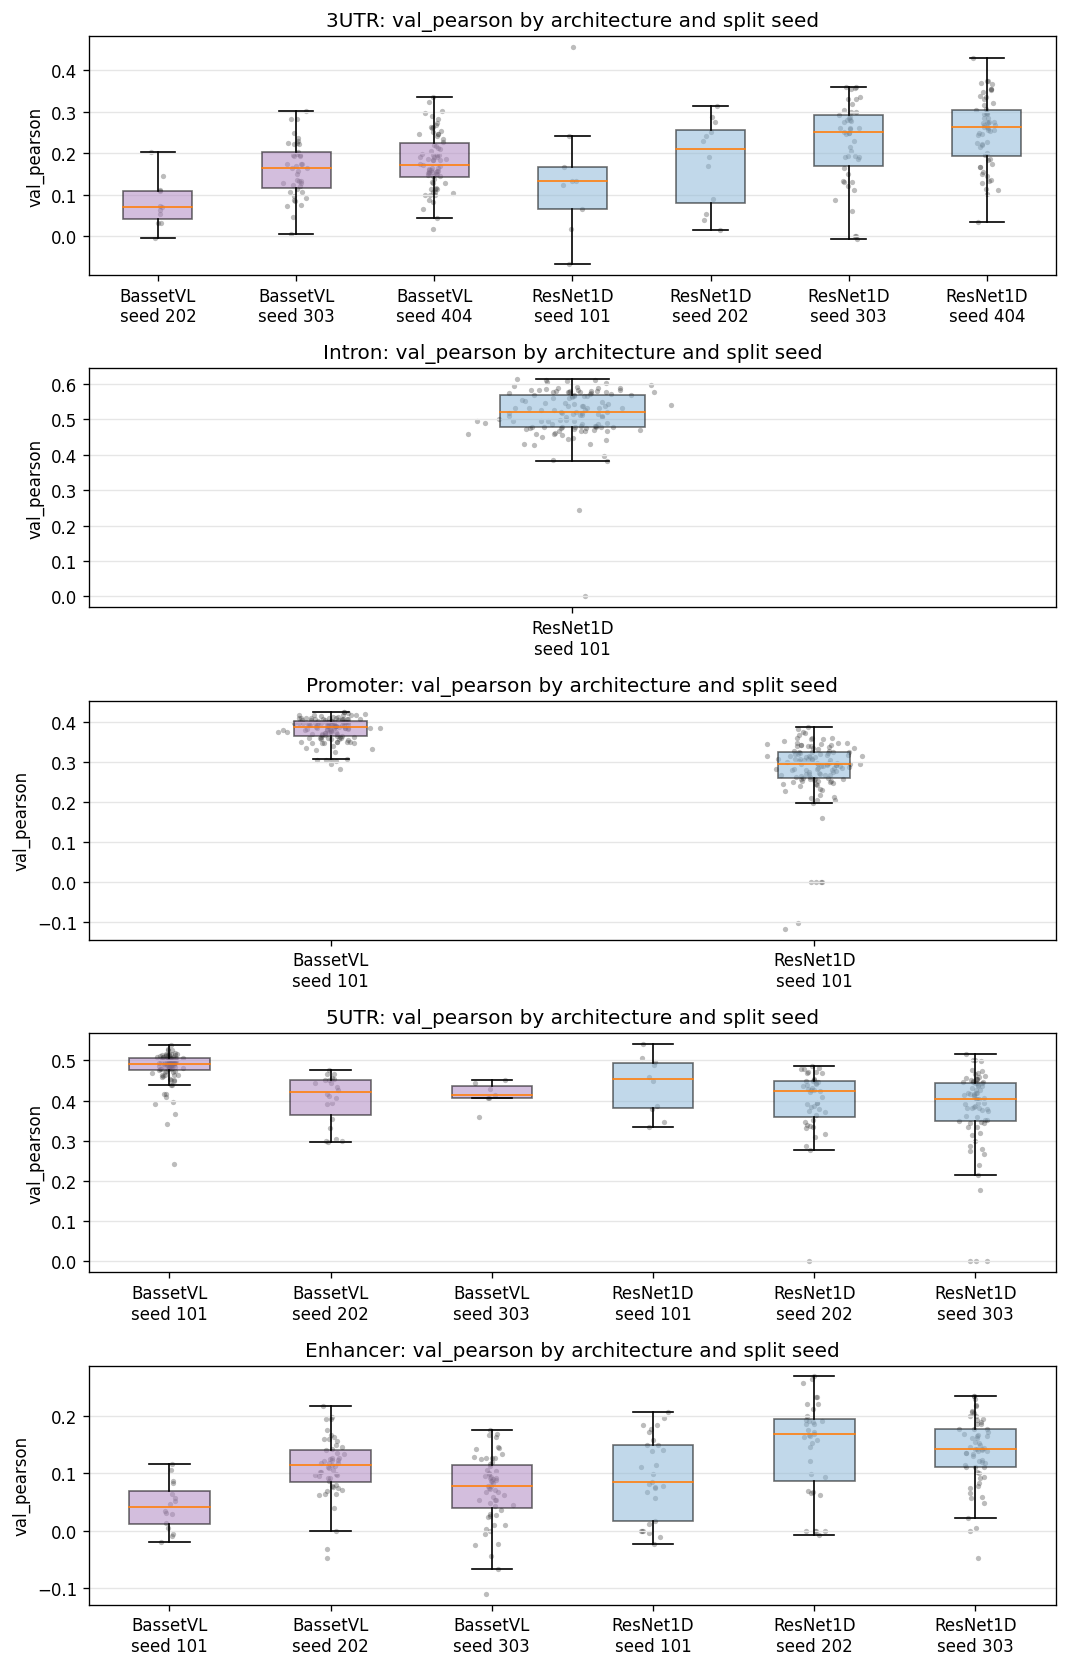

In [7]:
def plot_seed_distributions(df, metric='val_pearson'):
    plot_df = df[df['selection_ready'] & df[metric].notna()].copy()
    parts = list(dict.fromkeys(plot_df['cre_region'].tolist()))
    fig, axes = plt.subplots(len(parts), 1, figsize=(9, 2.8 * len(parts)), squeeze=False)
    for ax, part in zip(axes.ravel(), parts):
        sub = plot_df[plot_df['cre_region'].eq(part)].copy()
        labels = []
        data = []
        colors = []
        for (arch, seed), group in sub.groupby(['architecture', 'split_seed'], dropna=False):
            labels.append(f'{arch}\nseed {int(seed) if pd.notna(seed) else "NA"}')
            data.append(group[metric].dropna().to_numpy())
            colors.append('#8fb9d9' if arch == 'ResNet1D' else '#b08ac2')
        bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.55)
        for i, vals in enumerate(data, start=1):
            x = np.random.default_rng(i).normal(i, 0.04, size=len(vals))
            ax.scatter(x, vals, s=10, color='0.25', alpha=0.35, linewidth=0)
        ax.set_title(f'{part}: {metric} by architecture and split seed')
        ax.set_ylabel(metric)
        ax.grid(axis='y', color='0.9')
    fig.tight_layout()
    return fig, axes

fig, axes = plot_seed_distributions(hpo_cfg, metric='val_pearson')

## Shared Split Reconstruction

The data module chooses val/test like this:

1. Filter HQ rows with `n_barcodes >= test_min_barcodes`.
2. Create `perm = np.random.default_rng(split_seed).permutation(hq_df.index)`.
3. First `n_test` HQ indices become test.
4. Next `n_val` HQ indices become validation.
5. All remaining eligible rows become train for full-size HPO.

Therefore, for a given part and `split_seed`, heldout row IDs are shared across all configs with the same data policy. This cell reconstructs split IDs and gives each heldout set a hash so we can check identity and support paired comparisons later.

In [8]:
def read_sweep_config(config_path):
    path = Path(str(config_path))
    if not path.is_absolute():
        path = LEARN / path
    with path.open() as fh:
        return yaml.safe_load(fh), path


def parameter_values(config, key):
    spec = (config.get('parameters') or {}).get(key)
    if spec is None:
        return []
    if isinstance(spec, dict):
        if 'values' in spec:
            return list(spec['values'])
        if 'value' in spec:
            return [spec['value']]
    return [spec]


def unique_stable(values):
    out = []
    for value in values:
        if value not in out:
            out.append(value)
    return out


def sep_value(value):
    return '\t' if value in {'tab', '\\t', '\t'} else value


def display_part(task_family):
    return {'promoter': 'Promoter', 'introns': 'Intron', 'intron': 'Intron', 'utr3': '3UTR', 'utr5': '5UTR', 'enhancer': 'Enhancer'}.get(task_family, task_family)

finished_launches = sweep_launches[sweep_launches['sweep_id'].astype(str).isin(ORCHESTRATOR_SWEEP_IDS)].copy()


def params_for_part(task_family):
    rows = finished_launches[finished_launches['task_family'].eq(task_family)].copy()
    if rows.empty:
        raise ValueError(f'No launch rows for {task_family}')
    configs = []
    for config_path in rows['config_path'].dropna().drop_duplicates():
        cfg, _ = read_sweep_config(config_path)
        configs.append(cfg)
    keys = [
        'datafile_path', 'sep', 'sequence_column', 'target_column', 'barcode_column',
        'test_min_barcodes', 'train_min_barcodes', 'val_frac_within_hq', 'test_frac_within_hq',
        'val_size_within_hq', 'test_size_within_hq', 'train_size_frac', 'train_sampling_mode', 'split_seed',
    ]
    values_by_key = {key: [] for key in keys}
    for cfg in configs:
        for key in keys:
            values_by_key[key].extend(parameter_values(cfg, key))
    values_by_key = {key: unique_stable(vals) for key, vals in values_by_key.items()}
    params = {key: (vals[0] if vals else None) for key, vals in values_by_key.items()}
    params['split_seed_values'] = [int(x) for x in (values_by_key['split_seed'] or [params.get('split_seed')]) if x is not None]
    params['task_family'] = task_family
    return params

part_params = {task: params_for_part(task) for task in ['promoter', 'introns', 'utr3', 'utr5', 'enhancer']}


def load_part_frame(params):
    path = Path(params['datafile_path'])
    if not path.is_absolute():
        path = LEARN / path
    df = pd.read_csv(path, sep=sep_value(params.get('sep', '\t')), low_memory=False).copy()
    seq_col, target_col, barcode_col = params['sequence_column'], params['target_column'], params['barcode_column']
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df[barcode_col] = pd.to_numeric(df[barcode_col], errors='coerce')
    df = df.loc[df[seq_col].notna() & df[barcode_col].notna() & np.isfinite(df[target_col])].reset_index(drop=True)
    df['row_id'] = np.arange(len(df))
    return df


def assign_splits(df, params, split_seed):
    seq_col, target_col, barcode_col = params['sequence_column'], params['target_column'], params['barcode_column']
    test_min = int(params.get('test_min_barcodes') or 4)
    train_min = int(params.get('train_min_barcodes') or 1)
    val_size = params.get('val_size_within_hq')
    test_size = params.get('test_size_within_hq')
    val_frac = float(params.get('val_frac_within_hq') or 0.2)
    test_frac = float(params.get('test_frac_within_hq') or 0.2)

    hq_df = df.loc[df[barcode_col] >= test_min].copy()
    perm = np.random.default_rng(int(split_seed)).permutation(hq_df.index.to_numpy())
    n_hq = len(perm)
    n_test = int(test_size) if test_size is not None else max(1, int(round(n_hq * test_frac)))
    n_val = int(val_size) if val_size is not None else max(1, int(round(n_hq * val_frac)))
    if n_test + n_val >= n_hq:
        if test_size is not None or val_size is not None:
            raise ValueError(f'Requested val/test sizes ({n_val}/{n_test}) exhaust HQ rows ({n_hq})')
        n_test = max(1, n_hq // 5)
        n_val = max(1, n_hq // 5)

    test_idx = set(perm[:n_test].tolist())
    val_idx = set(perm[n_test:n_test + n_val].tolist())
    used = test_idx | val_idx
    rest = df.loc[~df.index.isin(used)].copy().reset_index(drop=True)
    train = rest.loc[rest[barcode_col] >= train_min].copy().reset_index(drop=True)

    pieces = []
    for split, idx in [('test', test_idx), ('val', val_idx)]:
        part = df.loc[df.index.isin(idx), ['row_id', seq_col, target_col, barcode_col]].copy()
        part['split'] = split
        pieces.append(part)
    train = train[['row_id', seq_col, target_col, barcode_col]].copy()
    train['split'] = 'train'
    pieces.append(train)
    assigned = pd.concat(pieces, ignore_index=True)
    assigned = assigned.rename(columns={seq_col: 'sequence', target_col: 'target', barcode_col: 'n_barcodes'})
    assigned['split_seed'] = int(split_seed)
    assigned['test_min_barcodes'] = test_min
    assigned['quality_bin'] = np.where(assigned['n_barcodes'] >= test_min, 'hq', 'low_barcode')
    return assigned

split_parts = []
for task, params in part_params.items():
    df = load_part_frame(params)
    for seed in params['split_seed_values']:
        assigned = assign_splits(df, params, seed)
        assigned['task_family'] = task
        assigned['part'] = display_part(task)
        split_parts.append(assigned)
split_assignments = pd.concat(split_parts, ignore_index=True)

def ids_hash(values):
    text = ','.join(map(str, sorted(map(int, values))))
    return str(abs(hash(text)))

split_hash_table = split_assignments.groupby(['part', 'task_family', 'split_seed', 'split'], as_index=False).agg(
    n_rows=('row_id', 'nunique'),
    n_hq=('quality_bin', lambda s: int((s == 'hq').sum())),
    n_low_barcode=('quality_bin', lambda s: int((s == 'low_barcode').sum())),
    target_std=('target', 'std'),
    target_iqr=('target', lambda s: s.quantile(0.75) - s.quantile(0.25)),
    row_id_hash=('row_id', ids_hash),
)
split_hash_table.sort_values(['part', 'split_seed', 'split'])

,part,task_family,split_seed,split,n_rows,n_hq,n_low_barcode,target_std,target_iqr,row_id_hash
0,3UTR,utr3,101,test,194,194,0,0.806282,0.582116,8407873161284189328
1,3UTR,utr3,101,train,6457,387,6070,0.893852,0.895303,119584406316124547
2,3UTR,utr3,101,val,194,194,0,0.741878,0.674027,4019058569636984504
3,3UTR,utr3,202,test,194,194,0,0.588264,0.489099,164736698970464992
4,3UTR,utr3,202,train,6457,387,6070,0.899580,0.902103,2322371176535653172
5,3UTR,utr3,202,val,194,194,0,0.727297,0.602241,2511805646534373815
6,3UTR,utr3,303,test,194,194,0,0.747126,0.603058,2880864023899055928
7,3UTR,utr3,303,train,6457,387,6070,0.891502,0.900912,7684200170718063024
8,3UTR,utr3,303,val,194,194,0,0.883895,0.483316,8298100662767355041
9,3UTR,utr3,404,test,194,194,0,0.608372,0.550684,1074892305478351420


In [9]:
# Attach the reconstructed split hash to each run, proving which runs share val/test IDs.
run_split_hashes = []
for _, row in hpo_cfg.iterrows():
    part = row['cre_region']
    seed = row['split_seed']
    if pd.isna(seed):
        continue
    for split in ['val', 'test']:
        match = split_hash_table[
            split_hash_table['part'].eq(part)
            & split_hash_table['split_seed'].eq(int(seed))
            & split_hash_table['split'].eq(split)
        ]
        if not match.empty:
            run_split_hashes.append({
                'run_id': row['run_id'],
                'cre_region': part,
                'architecture': row['architecture'],
                'split_seed': int(seed),
                'split': split,
                'row_id_hash': match['row_id_hash'].iloc[0],
                'n_rows': int(match['n_rows'].iloc[0]),
            })
run_split_hashes = pd.DataFrame(run_split_hashes)
shared_split_summary = run_split_hashes.groupby(['cre_region', 'split_seed', 'split', 'row_id_hash'], as_index=False).agg(
    n_runs_sharing=('run_id', 'nunique'),
    architectures=('architecture', lambda s: ','.join(sorted(set(map(str, s))))),
    n_rows=('n_rows', 'first'),
)
shared_split_summary.sort_values(['cre_region', 'split_seed', 'split'])

,cre_region,split_seed,split,row_id_hash,n_runs_sharing,architectures,n_rows
0,3UTR,101,test,8407873161284189328,9,ResNet1D,194
1,3UTR,101,val,4019058569636984504,9,ResNet1D,194
2,3UTR,202,test,164736698970464992,23,"BassetVL,ResNet1D",194
3,3UTR,202,val,2511805646534373815,23,"BassetVL,ResNet1D",194
4,3UTR,303,test,2880864023899055928,88,"BassetVL,ResNet1D",194
5,3UTR,303,val,8298100662767355041,88,"BassetVL,ResNet1D",194
6,3UTR,404,test,1074892305478351420,135,"BassetVL,ResNet1D",194
7,3UTR,404,val,5963870035190338543,135,"BassetVL,ResNet1D",194
8,5UTR,101,test,427762011720156539,109,"BassetVL,ResNet1D",250
9,5UTR,101,val,6863928262608686077,109,"BassetVL,ResNet1D",250



## Fisher CI Plots For Current Leaders

Fisher intervals are finite-heldout uncertainty intervals. They do not include split difficulty or model randomness, but they help prevent overinterpreting tiny differences among top runs.

Selection labels:

- `selected_by_val_pearson`: within a part-architecture HPO sweep, this is the run with the highest logged validation Pearson.
- `selected_by_test_pearson_diagnostic`: within a part-architecture HPO sweep, this is the run with the highest logged test Pearson. This is diagnostic only; it should not be the primary model-selection rule if we want the test set to remain an unbiased final evaluation.

A plot with x-axis `val Pearson` can still include a `selected_by_test_pearson_diagnostic` run: it means we selected that run by its test Pearson, then plotted its validation Pearson and Fisher CI. Likewise, a `test Pearson` plot can include `selected_by_val_pearson` runs: select by validation Pearson, then inspect test Pearson.

Because checkpoint/early stopping is validation-driven, every run's saved checkpoint is still the epoch selected by validation performance. A `selected_by_test_pearson_diagnostic` run is not a checkpoint chosen by its best test epoch; it is a run whose validation-selected checkpoint happened to have the highest final logged test Pearson among the HPO runs.

These plots use reconstructed `n` for the run's split seed and the registry Pearson value.


In [10]:

def fisher_pearson_ci(r, n, alpha=0.05):
    if pd.isna(r) or pd.isna(n) or n <= 3:
        return (np.nan, np.nan)
    r = float(np.clip(r, -0.999999, 0.999999))
    z = np.arctanh(r)
    zcrit = 1.959963984540054
    se = 1.0 / math.sqrt(float(n) - 3.0)
    return tuple(np.tanh([z - zcrit * se, z + zcrit * se]).astype(float))


def top_by_metric(df, metric, label, group_cols):
    ok = df[df['selection_ready'] & df[metric].notna()].copy()
    top = ok.sort_values(metric, ascending=False).groupby(list(group_cols), as_index=False).head(1)
    top.insert(0, 'selection_label', label)
    return top

# The downstream decision unit is part-architecture/HPO project, so these are the primary leader tables.
val_best_by_project = top_by_metric(hpo_cfg, 'val_pearson', 'selected_by_val_pearson', ['logger_project'])
test_best_by_project = top_by_metric(hpo_cfg, 'test_pearson', 'selected_by_test_pearson_diagnostic', ['logger_project'])
project_leader_table = pd.concat([val_best_by_project, test_best_by_project], ignore_index=True)
project_leader_table = project_leader_table.drop_duplicates(['selection_label', 'logger_project', 'run_id']).copy()

# Unique checkpoint candidates to evaluate on train_all/train_hq/train_low_barcode/val/test.
checkpoint_candidate_table = project_leader_table.drop_duplicates('run_id').copy()
selection_label_map = project_leader_table.groupby('run_id')['selection_label'].agg(lambda s: ','.join(sorted(set(map(str, s)))))
checkpoint_candidate_table['selection_labels'] = checkpoint_candidate_table['run_id'].map(selection_label_map)

# Compact CRE-level leaders are still useful for a one-row-per-CRE narrative figure.
val_best_by_cre = top_by_metric(hpo_cfg, 'val_pearson', 'selected_by_val_pearson_cre', ['cre_region'])
test_best_by_cre = top_by_metric(hpo_cfg, 'test_pearson', 'selected_by_test_pearson_diagnostic_cre', ['cre_region'])
cre_leader_table = pd.concat([val_best_by_cre, test_best_by_cre], ignore_index=True)
cre_leader_table = cre_leader_table.drop_duplicates(['selection_label', 'cre_region', 'run_id']).copy()


def split_n_for_run(row, split):
    seed = row.get('split_seed')
    if pd.isna(seed):
        return np.nan
    match = split_hash_table[
        split_hash_table['part'].eq(row['cre_region'])
        & split_hash_table['split_seed'].eq(int(seed))
        & split_hash_table['split'].eq(split)
    ]
    return int(match['n_rows'].iloc[0]) if not match.empty else np.nan


def add_fisher_ci(table):
    ci_rows = []
    for _, row in table.iterrows():
        rec = row.to_dict()
        for split in ['val', 'test']:
            n = split_n_for_run(row, split)
            r = row[f'{split}_pearson']
            lo, hi = fisher_pearson_ci(r, n)
            rec[f'{split}_n'] = n
            rec[f'{split}_ci_low'] = lo
            rec[f'{split}_ci_high'] = hi
        ci_rows.append(rec)
    return pd.DataFrame(ci_rows)

project_leader_ci = add_fisher_ci(project_leader_table)
cre_leader_ci = add_fisher_ci(cre_leader_table)
project_leader_ci[['selection_label','cre_region','architecture','run_id','split_seed','val_n','val_pearson','val_ci_low','val_ci_high','test_n','test_pearson','test_ci_low','test_ci_high']].sort_values(['cre_region','architecture','selection_label'])


,selection_label,cre_region,architecture,run_id,split_seed,val_n,val_pearson,val_ci_low,val_ci_high,test_n,test_pearson,test_ci_low,test_ci_high
10,selected_by_test_pearson_diagnostic,3UTR,BassetVL,pn50zxhm,303,194,0.282984,0.148009,0.407609,194,0.586879,0.486202,0.672180
6,selected_by_val_pearson,3UTR,BassetVL,utc3cqzn,404,194,0.335262,0.204023,0.454663,194,0.281119,0.146027,0.405918
12,selected_by_test_pearson_diagnostic,3UTR,ResNet1D,39glhfll,303,194,0.353463,0.223729,0.470891,194,0.477185,0.360547,0.579129
3,selected_by_val_pearson,3UTR,ResNet1D,8xcp9her,101,194,0.455851,0.336591,0.560718,194,0.085764,-0.055785,0.223933
13,selected_by_test_pearson_diagnostic,5UTR,BassetVL,a5zoy95n,303,250,0.451856,0.347256,0.545350,250,0.458869,0.355014,0.551537
2,selected_by_val_pearson,5UTR,BassetVL,n9lzq306,101,250,0.538877,0.444530,0.621399,250,0.344869,0.230672,0.449695
11,selected_by_test_pearson_diagnostic,5UTR,ResNet1D,yydnds86,303,250,0.468385,0.365561,0.559914,250,0.498117,0.398688,0.585971
1,selected_by_val_pearson,5UTR,ResNet1D,4a2z7obx,101,250,0.540936,0.446858,0.623180,250,0.367017,0.254541,0.469697
16,selected_by_test_pearson_diagnostic,Enhancer,BassetVL,f0e9s0ef,202,250,0.195890,0.073612,0.312366,250,0.227071,0.105990,0.341517
8,selected_by_val_pearson,Enhancer,BassetVL,rbdf02tt,202,250,0.217002,0.095507,0.332128,250,0.136143,0.012283,0.255888


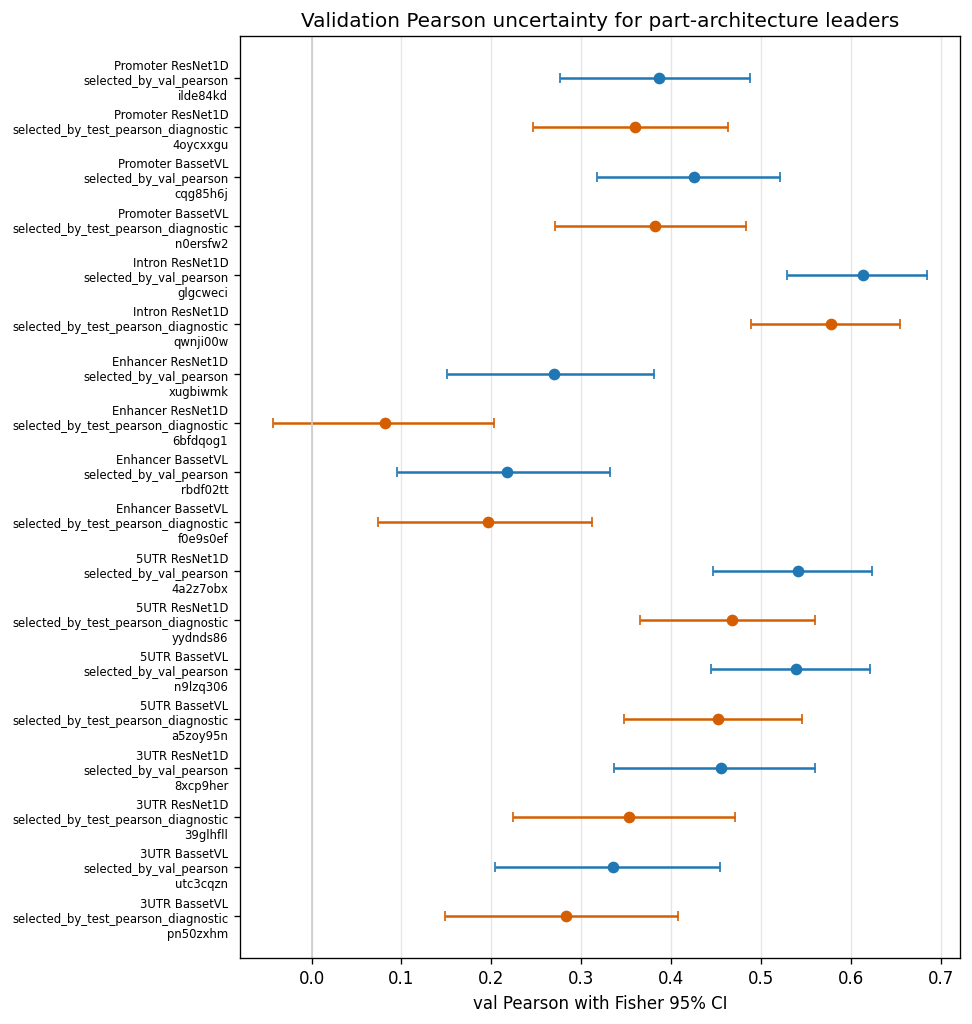

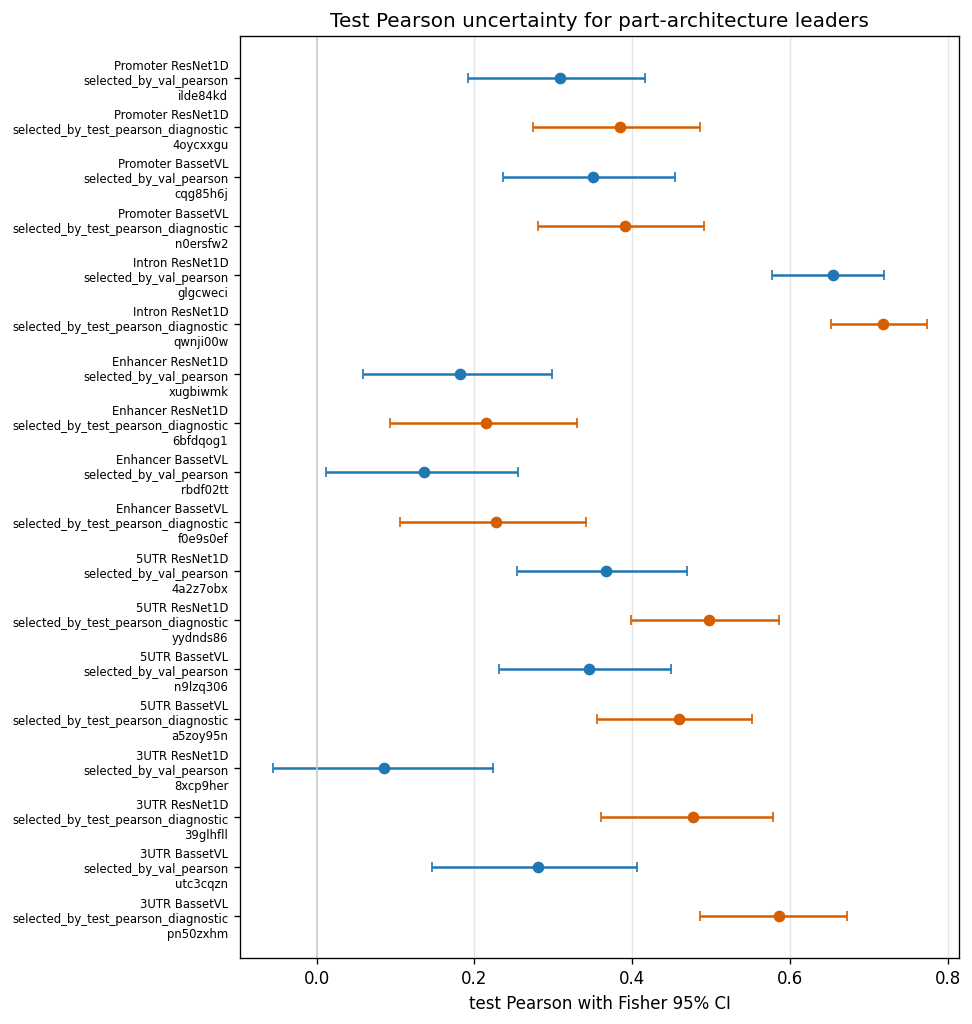

In [11]:

def plot_leader_fisher_ci(ci_df, split='val', title=None):
    plot_df = ci_df.copy().sort_values(['cre_region', 'architecture', 'selection_label'])
    labels = plot_df.apply(lambda r: f"{r['cre_region']} {r['architecture']}\n{r['selection_label']}\n{r['run_id']}", axis=1).tolist()
    y = np.arange(len(plot_df))
    r = plot_df[f'{split}_pearson'].to_numpy(dtype=float)
    lo = plot_df[f'{split}_ci_low'].to_numpy(dtype=float)
    hi = plot_df[f'{split}_ci_high'].to_numpy(dtype=float)
    colors = plot_df['selection_label'].map({
        'selected_by_val_pearson': '#1f77b4',
        'selected_by_test_pearson_diagnostic': '#d55e00',
        'selected_by_val_pearson_cre': '#1f77b4',
        'selected_by_test_pearson_diagnostic_cre': '#d55e00',
    }).fillna('0.4')
    fig, ax = plt.subplots(figsize=(8.2, max(4.5, 0.48 * len(plot_df))))
    for i, (rv, lov, hiv, color) in enumerate(zip(r, lo, hi, colors)):
        ax.errorbar(rv, i, xerr=[[rv - lov], [hiv - rv]], fmt='o', color=color, ecolor=color, capsize=3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=7)
    ax.axvline(0, color='0.8', linewidth=1)
    ax.set_xlabel(f'{split} Pearson with Fisher 95% CI')
    ax.set_title(title or f'{split.capitalize()} Pearson uncertainty')
    ax.grid(axis='x', color='0.9')
    fig.tight_layout()
    return fig, ax

fig, ax = plot_leader_fisher_ci(project_leader_ci, split='val', title='Validation Pearson uncertainty for part-architecture leaders')
fig, ax = plot_leader_fisher_ci(project_leader_ci, split='test', title='Test Pearson uncertainty for part-architecture leaders')

# Optional compact view:
# fig, ax = plot_leader_fisher_ci(cre_leader_ci, split='val', title='Validation Pearson uncertainty for CRE-level leaders')
# fig, ax = plot_leader_fisher_ci(cre_leader_ci, split='test', title='Test Pearson uncertainty for CRE-level leaders')


## Split-Aware Checkpoint Evaluation

This is the practical test of the low-barcode-noise explanation.

For a selected checkpoint, evaluate one trained model on:

- `train_all`: all training rows used by the run.
- `train_hq`: training rows with `n_barcodes >= test_min_barcodes`.
- `train_low_barcode`: training rows below heldout barcode threshold.
- `val`: validation heldout.
- `test`: untouched test heldout.

Expected supporting evidence:

- `train_hq` Pearson and residual scale should be closer to val/test than `train_low_barcode` is.
- Residual fan-out should be largest at low barcode counts.
- COD R2 should be reviewed alongside Pearson to catch scale/offset failures. We do not need calibration slope as a primary metric right now.

The heavy cell below is guarded. It needs `torch` and BODA imports, and may take time.

In [12]:
def locate_artifact(row):
    path = row.get('artifact_path')
    if isinstance(path, str) and path and Path(path).exists():
        return Path(path)
    project = str(row.get('logger_project'))
    run_id = str(row.get('run_id'))
    candidates = sorted((LEARN / 'local_artifacts').glob(f'**/*{project}*{run_id}*.tar.gz'))
    if candidates:
        return candidates[0]
    candidates = sorted((LEARN / 'outputs' / 'hpo_runs' / 'by_project').glob(f'**/{run_id}/model_artifacts.tar.gz'))
    return candidates[0] if candidates else None

artifact_audit = checkpoint_candidate_table.copy()
artifact_audit['artifact_path_resolved'] = artifact_audit.apply(locate_artifact, axis=1).map(lambda p: str(p) if p else None)
artifact_audit['artifact_found'] = artifact_audit['artifact_path_resolved'].notna()
artifact_audit[['selection_labels','cre_region','architecture','run_id','artifact_found','artifact_path_resolved']].sort_values(['cre_region','architecture','selection_labels'])


,selection_labels,cre_region,architecture,run_id,artifact_found,artifact_path_resolved
10,selected_by_test_pearson_diagnostic,3UTR,BassetVL,pn50zxhm,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/bashor_in_house/threeprime_modal100/utr_bassetvl/scratch_fp32_bayes/model_artifacts__utr3__bashor_in_house__thre...
6,selected_by_val_pearson,3UTR,BassetVL,utc3cqzn,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/bashor_in_house/threeprime_modal100/utr_bassetvl/scratch_fp32_bayes/model_artifacts__utr3__bashor_in_house__thre...
12,selected_by_test_pearson_diagnostic,3UTR,ResNet1D,39glhfll,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/bashor_in_house/threeprime_modal100/resnet1d/scratch_fp32_bayes/model_artifacts__utr3__bashor_in_house__threepri...
3,selected_by_val_pearson,3UTR,ResNet1D,8xcp9her,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr3/bashor_in_house/threeprime_modal100/resnet1d/scratch_fp32_bayes/model_artifacts__utr3__bashor_in_house__threepri...
13,selected_by_test_pearson_diagnostic,5UTR,BassetVL,a5zoy95n,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/bashor_in_house/fiveprime_modal50/utr_bassetvl/scratch_fp32_bayes/model_artifacts__utr5__bashor_in_house__fivepr...
2,selected_by_val_pearson,5UTR,BassetVL,n9lzq306,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/bashor_in_house/fiveprime_modal50/utr_bassetvl/scratch_fp32_bayes/model_artifacts__utr5__bashor_in_house__fivepr...
11,selected_by_test_pearson_diagnostic,5UTR,ResNet1D,yydnds86,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/bashor_in_house/fiveprime_modal50/resnet1d/scratch_fp32_bayes/model_artifacts__utr5__bashor_in_house__fiveprime_...
1,selected_by_val_pearson,5UTR,ResNet1D,4a2z7obx,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/bashor_in_house/fiveprime_modal50/resnet1d/scratch_fp32_bayes/model_artifacts__utr5__bashor_in_house__fiveprime_...
16,selected_by_test_pearson_diagnostic,Enhancer,BassetVL,f0e9s0ef,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/enhancer/bashor_in_house/no_flank_hq8/bassetvl/scratch_fp32_bayes/model_artifacts__enhancer__bashor_in_house__no_flan...
8,selected_by_val_pearson,Enhancer,BassetVL,rbdf02tt,True,/home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/enhancer/bashor_in_house/no_flank_hq8/bassetvl/scratch_fp32_bayes/model_artifacts__enhancer__bashor_in_house__no_flan...


In [13]:
RUN_HEAVY_CHECKPOINT_EVAL = True
# Choose what to evaluate when the heavy switch is enabled.
# Good default: val-best and test-best unique checkpoint candidates for each part-architecture HPO project.
EVAL_RUN_TABLE = checkpoint_candidate_table.copy()


def pearson_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[ok], y_pred[ok]
    if len(y_true) < 3 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def spearman_np(y_true, y_pred):
    return pd.Series(y_true).corr(pd.Series(y_pred), method='spearman')


def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.sqrt(np.mean((y_true[ok] - y_pred[ok]) ** 2))) if ok.sum() else np.nan


def cod_r2_np(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[ok], y_pred[ok]
    if len(y_true) < 2:
        return np.nan
    denom = np.sum((y_true - np.mean(y_true)) ** 2)
    if denom <= 0:
        return np.nan
    return float(1.0 - np.sum((y_true - y_pred) ** 2) / denom)


def regression_metrics(frame, true_col='true_raw', pred_col='pred_raw'):
    y = frame[true_col].to_numpy(dtype=float)
    p = frame[pred_col].to_numpy(dtype=float)
    residual = y - p
    return {
        'n': int(np.isfinite(y).sum()),
        'pearson': pearson_np(y, p),
        'spearman': spearman_np(y, p),
        'rmse': rmse_np(y, p),
        'cod_r2': cod_r2_np(y, p),
        'mse': float(np.nanmean(residual ** 2)),
        'mae': float(np.nanmean(np.abs(residual))),
        'residual_mean': float(np.nanmean(residual)),
        'abs_residual_median': float(np.nanmedian(np.abs(residual))),
    }


def load_model_and_data_from_artifact(artifact_path, device=None):
    import torch
    import boda

    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    artifact_path = Path(artifact_path)
    with tempfile.TemporaryDirectory() as tmpdir:
        with tarfile.open(artifact_path, 'r:gz') as tar:
            tar.extractall(tmpdir)
        ckpt_path = Path(tmpdir) / 'artifacts' / 'torch_checkpoint.pt'
        ckpt = torch.load(ckpt_path, map_location='cpu')

    data_cls = getattr(boda.data, ckpt['data_module'])
    model_cls = getattr(boda.model, ckpt['model_module'])
    data = data_cls(**vars(ckpt['data_hparams']))
    data.setup()
    model = model_cls(**vars(ckpt['model_hparams']))
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval().to(device)
    return model, data, ckpt


def predict_frame(model, data, frame, batch_size=512, device=None):
    import torch
    from torch.utils.data import DataLoader

    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    ds = data._df_to_dataset(frame.copy(), training=False)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    preds, labels = [], []
    model.eval().to(device)
    with torch.no_grad():
        for batch in loader:
            x, y = batch[:2]
            yhat = model(x.to(device)).detach().cpu()
            if yhat.ndim == 2 and yhat.shape[1] == 1:
                yhat = yhat[:, 0]
            if y.ndim == 2 and y.shape[1] == 1:
                y = y[:, 0]
            preds.append(yhat)
            labels.append(y.detach().cpu())
    pred_scaled = torch.cat(preds).numpy()
    true_scaled = torch.cat(labels).numpy()
    out = frame.reset_index(drop=True).copy()
    out['pred_scaled'] = pred_scaled
    out['true_scaled'] = true_scaled
    out['pred_raw'] = pred_scaled * data.target_std + data.target_mean if getattr(data, 'normalize', True) else pred_scaled
    out['true_raw'] = true_scaled * data.target_std + data.target_mean if getattr(data, 'normalize', True) else true_scaled
    out['residual_raw'] = out['true_raw'] - out['pred_raw']
    out['abs_residual_raw'] = out['residual_raw'].abs()
    return out


def evaluate_quality_splits(row, device=None):
    artifact = locate_artifact(row)
    if artifact is None:
        raise FileNotFoundError(f"No artifact found for {row['run_id']}")
    model, data, ckpt = load_model_and_data_from_artifact(artifact, device=device)
    barcode_col = data.barcode_column
    test_min = data.test_min_barcodes
    frames = {
        'train_all': data.df_train,
        'train_hq': data.df_train[data.df_train[barcode_col] >= test_min].copy(),
        'train_low_barcode': data.df_train[data.df_train[barcode_col] < test_min].copy(),
        'val': data.df_val,
        'test': data.df_test,
    }
    pred_parts = []
    metric_rows = []
    for eval_split, frame in frames.items():
        pred = predict_frame(model, data, frame, device=device)
        pred['eval_split'] = eval_split
        pred['run_id'] = row['run_id']
        pred['cre_region'] = row['cre_region']
        pred['architecture'] = row['architecture']
        pred['split_seed'] = row.get('split_seed')
        pred['use_reverse_complements'] = row.get('use_reverse_complements')
        pred['selection_labels'] = row.get('selection_labels', row.get('selection_label'))
        pred_parts.append(pred)
        metric_rows.append({'run_id': row['run_id'], 'selection_labels': row.get('selection_labels', row.get('selection_label')), 'cre_region': row['cre_region'], 'architecture': row['architecture'], 'eval_split': eval_split, **regression_metrics(pred)})
    return pd.DataFrame(metric_rows), pd.concat(pred_parts, ignore_index=True)

if RUN_HEAVY_CHECKPOINT_EVAL:
    metric_tables = []
    prediction_tables = []
    for _, row in EVAL_RUN_TABLE.iterrows():
        metrics, preds = evaluate_quality_splits(row)
        metric_tables.append(metrics)
        prediction_tables.append(preds)
    checkpoint_eval_metrics = pd.concat(metric_tables, ignore_index=True)
    checkpoint_eval_predictions = pd.concat(prediction_tables, ignore_index=True)
    display(checkpoint_eval_metrics.sort_values(['cre_region', 'architecture', 'eval_split']))
else:
    print('Heavy checkpoint evaluation skipped. Set RUN_HEAVY_CHECKPOINT_EVAL=True when ready.')


,run_id,selection_labels,cre_region,architecture,eval_split,n,pearson,spearman,rmse,cod_r2,mse,mae,residual_mean,abs_residual_median
34,utc3cqzn,selected_by_val_pearson,3UTR,BassetVL,test,194,0.281119,0.286289,0.582610,0.078146,0.339434,0.398844,0.014584,0.271679
54,pn50zxhm,selected_by_test_pearson_diagnostic,3UTR,BassetVL,test,194,0.586879,0.264235,0.636164,0.271224,0.404704,0.430014,-0.187087,0.300656
30,utc3cqzn,selected_by_val_pearson,3UTR,BassetVL,train_all,6457,0.762998,0.689469,0.675794,0.434359,0.456698,0.502822,0.078695,0.382423
50,pn50zxhm,selected_by_test_pearson_diagnostic,3UTR,BassetVL,train_all,6457,0.595933,0.536495,0.767642,0.258450,0.589275,0.554467,-0.154588,0.411399
31,utc3cqzn,selected_by_val_pearson,3UTR,BassetVL,train_hq,387,0.834836,0.603589,0.456333,0.633255,0.208240,0.345569,0.037749,0.268275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,4oycxxgu,selected_by_test_pearson_diagnostic,Promoter,ResNet1D,train_hq,1431,0.768836,0.730676,0.405816,0.332475,0.164687,0.323104,-0.249786,0.277596
27,ilde84kd,selected_by_val_pearson,Promoter,ResNet1D,train_low_barcode,5962,0.694919,0.663365,0.681654,-0.015816,0.464652,0.558147,0.477512,0.506535
77,4oycxxgu,selected_by_test_pearson_diagnostic,Promoter,ResNet1D,train_low_barcode,5962,0.781826,0.746640,0.480690,0.494852,0.231063,0.378262,-0.221223,0.318339
28,ilde84kd,selected_by_val_pearson,Promoter,ResNet1D,val,250,0.413495,0.407839,0.619169,-0.841402,0.383370,0.504658,0.394102,0.447447


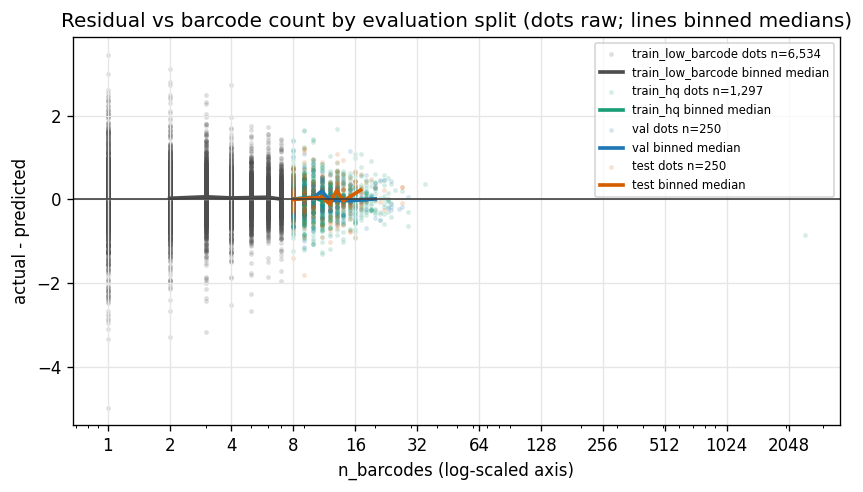

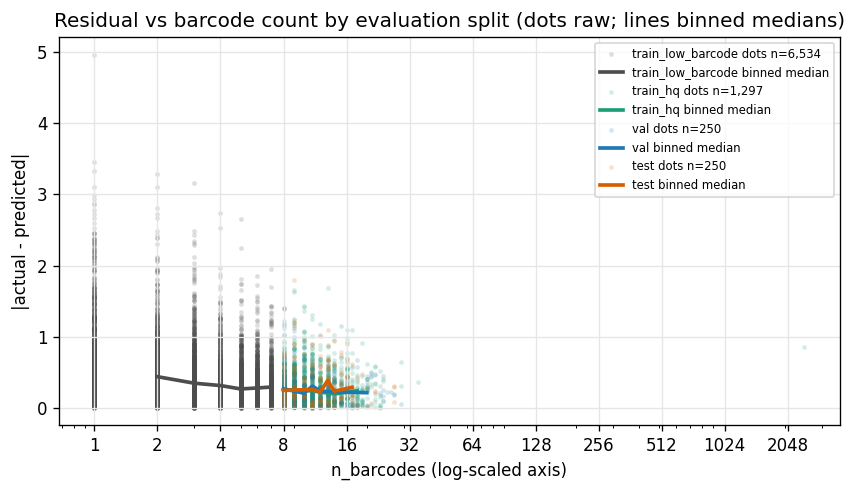

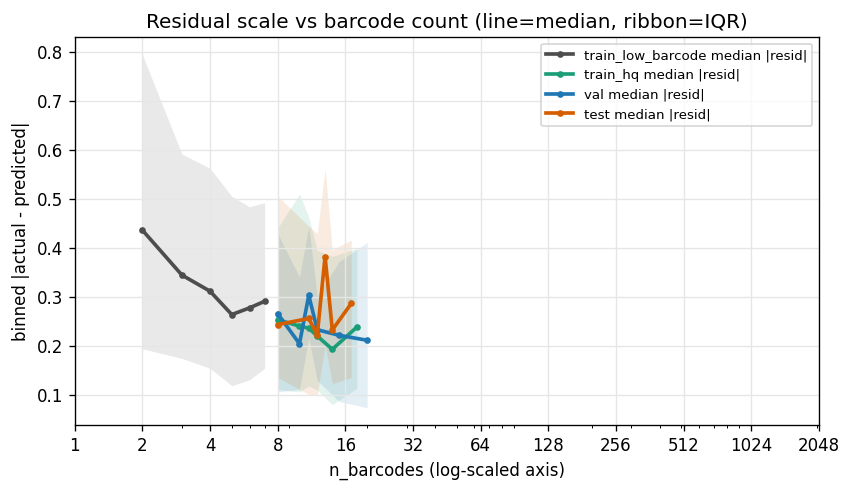

In [14]:

def _binned_barcode_summary(barcodes, y, n_bins=8):
    barcodes = np.asarray(barcodes, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(barcodes) & np.isfinite(y) & (barcodes > 0)
    barcodes, y = barcodes[ok], y[ok]
    if len(barcodes) < 30:
        return pd.DataFrame()
    # Bin in log space so low barcode counts are not compressed by a few high-count outliers,
    # but plot the bin centers as actual barcode counts.
    x_for_bins = np.log1p(barcodes)
    n_bins = min(int(n_bins), len(np.unique(x_for_bins)))
    if n_bins < 2:
        return pd.DataFrame()
    bins = np.quantile(x_for_bins, np.linspace(0, 1, n_bins + 1))
    bins = np.unique(bins)
    if len(bins) <= 2:
        return pd.DataFrame()
    idx = np.digitize(x_for_bins, bins[1:-1], right=True)
    return pd.DataFrame({'bin': idx, 'barcode': barcodes, 'y': y}).groupby('bin', as_index=False).agg(
        barcode=('barcode', 'median'),
        y_median=('y', 'median'),
        y_q25=('y', lambda s: np.quantile(s, 0.25)),
        y_q75=('y', lambda s: np.quantile(s, 0.75)),
        n=('y', 'size'),
    )


def _format_barcode_xaxis(ax, values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    if len(values) == 0:
        ax.set_xlabel('n_barcodes')
        return
    xmin, xmax = float(np.nanmin(values)), float(np.nanmax(values))
    ax.set_xscale('log')
    base_ticks = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192], dtype=float)
    ticks = base_ticks[(base_ticks >= max(1, xmin * 0.9)) & (base_ticks <= xmax * 1.1)]
    if len(ticks) < 3:
        unique_vals = np.unique(values.astype(int))
        ticks = unique_vals[:12] if len(unique_vals) > 12 else unique_vals
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) if float(t).is_integer() else f'{t:g}' for t in ticks])
    ax.set_xlabel('n_barcodes (log-scaled axis)')


def plot_residual_vs_barcode_combined(predictions, run_id=None, absolute=False, add_binned_median=True):
    """Plot raw residual dots plus optional binned median lines.

    The x-axis shows actual barcode counts on a log scale. With signed residuals,
    the binned line is a bias diagnostic: median(actual - predicted) at each
    barcode-count bin. For label-noise/residual-scale diagnosis, use absolute=True
    or plot_binned_residual_scale_vs_barcode below.
    """
    plot_df = predictions.copy()
    if run_id is not None:
        plot_df = plot_df[plot_df['run_id'].astype(str).eq(str(run_id))]
    if plot_df.empty:
        raise ValueError('No predictions to plot')
    y_col = 'abs_residual_raw' if absolute else 'residual_raw'
    ylabel = '|actual - predicted|' if absolute else 'actual - predicted'
    split_order = ['train_low_barcode', 'train_hq', 'val', 'test']
    colors = {'train_low_barcode': '#4d4d4d', 'train_hq': '#1b9e77', 'val': '#1f77b4', 'test': '#d55e00'}
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    all_barcodes = []
    for split in split_order:
        sub = plot_df[plot_df['eval_split'].eq(split)].copy()
        if sub.empty:
            continue
        x = sub['n_barcodes'].to_numpy(dtype=float)
        y = sub[y_col].to_numpy(dtype=float)
        ok = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x, y = x[ok], y[ok]
        all_barcodes.extend(x.tolist())
        ax.scatter(x, y, s=8, alpha=0.18, linewidth=0, label=f'{split} dots n={len(x):,}', color=colors.get(split, '0.5'))
        if add_binned_median:
            med = _binned_barcode_summary(x, y)
            if not med.empty:
                ax.plot(med['barcode'], med['y_median'], color=colors.get(split, '0.5'), linewidth=2.2, label=f'{split} binned median')
    if not absolute:
        ax.axhline(0, color='0.25', linewidth=1)
    _format_barcode_xaxis(ax, all_barcodes)
    ax.set_ylabel(ylabel)
    line_note = 'dots raw; lines binned medians' if add_binned_median else 'raw dots only'
    ax.set_title(f'Residual vs barcode count by evaluation split ({line_note})')
    ax.legend(frameon=True, fontsize=7, loc='best', ncol=1)
    ax.grid(color='0.9')
    fig.tight_layout()
    return fig, ax


def plot_binned_residual_scale_vs_barcode(predictions, run_id=None, n_bins=8):
    """Plot binned median absolute residual with an IQR ribbon.

    The x-axis shows actual barcode counts on a log scale. This plot is usually
    more directly relevant than signed residuals for asking whether low-barcode
    labels are noisier or harder to predict.
    """
    plot_df = predictions.copy()
    if run_id is not None:
        plot_df = plot_df[plot_df['run_id'].astype(str).eq(str(run_id))]
    if plot_df.empty:
        raise ValueError('No predictions to plot')
    split_order = ['train_low_barcode', 'train_hq', 'val', 'test']
    colors = {'train_low_barcode': '#4d4d4d', 'train_hq': '#1b9e77', 'val': '#1f77b4', 'test': '#d55e00'}
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    all_barcodes = []
    for split in split_order:
        sub = plot_df[plot_df['eval_split'].eq(split)].copy()
        if sub.empty:
            continue
        x = sub['n_barcodes'].to_numpy(dtype=float)
        y = sub['abs_residual_raw'].to_numpy(dtype=float)
        all_barcodes.extend(x[np.isfinite(x) & (x > 0)].tolist())
        binned = _binned_barcode_summary(x, y, n_bins=n_bins)
        if binned.empty:
            continue
        color = colors.get(split, '0.5')
        ax.plot(binned['barcode'], binned['y_median'], color=color, linewidth=2.2, marker='o', markersize=3, label=f'{split} median |resid|')
        ax.fill_between(binned['barcode'], binned['y_q25'], binned['y_q75'], color=color, alpha=0.12, linewidth=0)
    _format_barcode_xaxis(ax, all_barcodes)
    ax.set_ylabel('binned |actual - predicted|')
    ax.set_title('Residual scale vs barcode count (line=median, ribbon=IQR)')
    ax.legend(frameon=True, fontsize=8, loc='best')
    ax.grid(color='0.9')
    fig.tight_layout()
    return fig, ax

# After heavy eval:
# 5UTR
if 'checkpoint_eval_predictions' in globals():
    fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id='4a2z7obx', absolute=False)
    fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id='4a2z7obx', absolute=True)
    fig, ax = plot_binned_residual_scale_vs_barcode(checkpoint_eval_predictions, run_id='4a2z7obx')
else:
    print('Residual plots skipped. Run checkpoint evaluation first to create checkpoint_eval_predictions.')


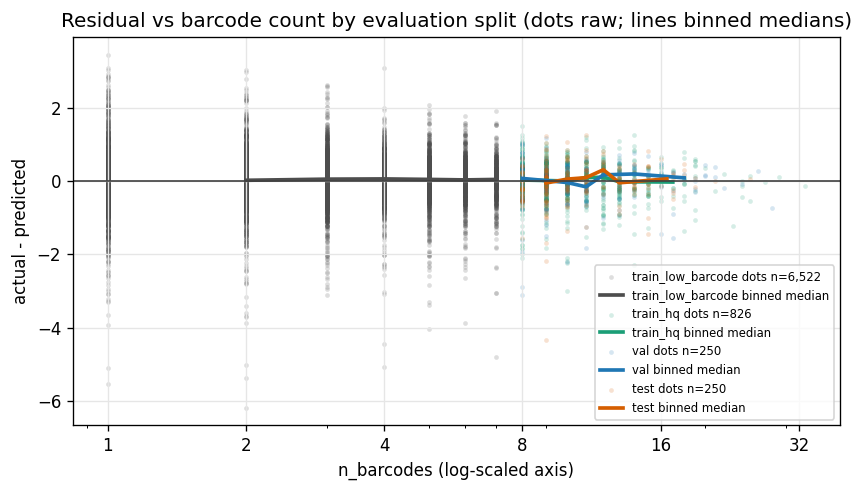

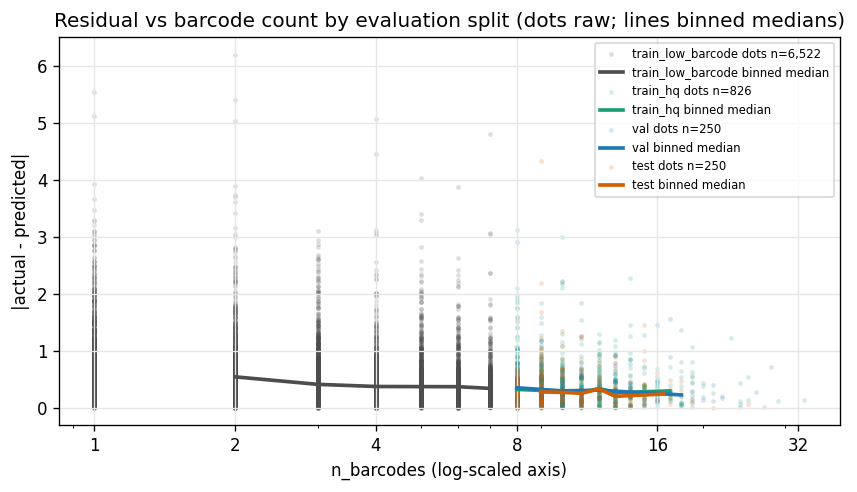

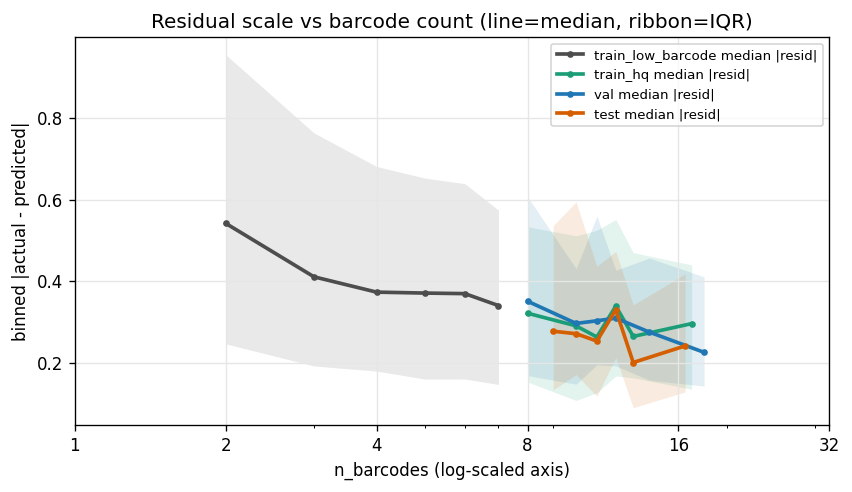

In [15]:
# Intron
if 'checkpoint_eval_predictions' in globals():
    fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id='glgcweci', absolute=False)
    fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id='glgcweci', absolute=True)
    fig, ax = plot_binned_residual_scale_vs_barcode(checkpoint_eval_predictions, run_id='glgcweci')
else:
    print('Residual plots skipped. Run checkpoint evaluation first to create checkpoint_eval_predictions.')

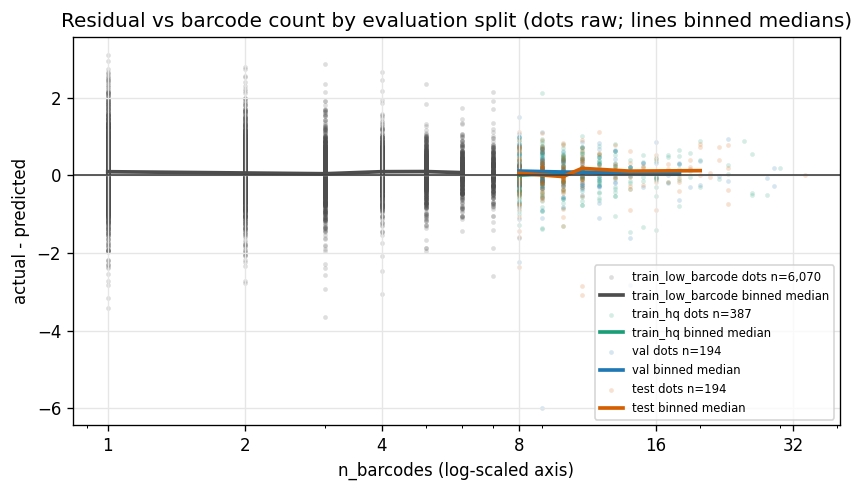

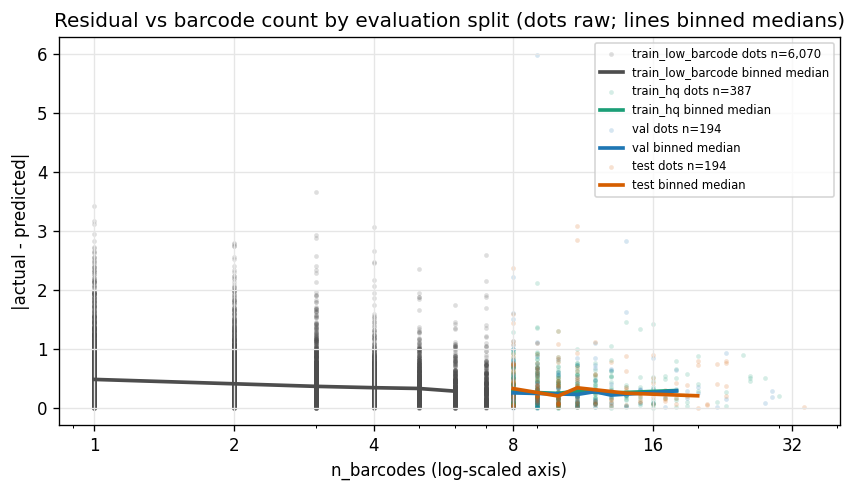

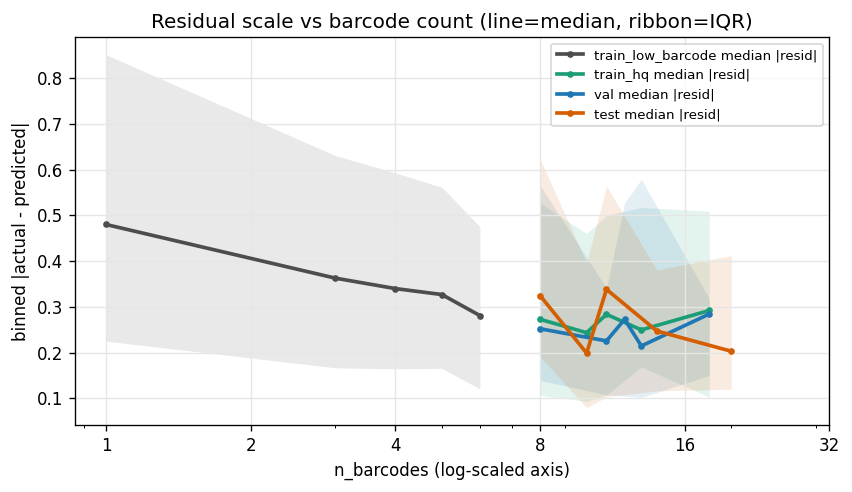

In [16]:
# 3UTR 
if 'checkpoint_eval_predictions' in globals():
    fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id='utc3cqzn', absolute=False)
    fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id='utc3cqzn', absolute=True)
    fig, ax = plot_binned_residual_scale_vs_barcode(checkpoint_eval_predictions, run_id='utc3cqzn')
else:
    print('Residual plots skipped. Run checkpoint evaluation first to create checkpoint_eval_predictions.')


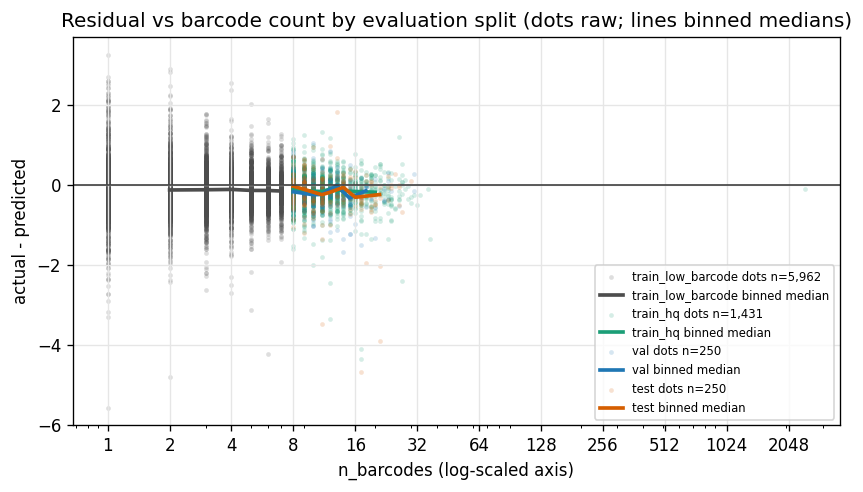

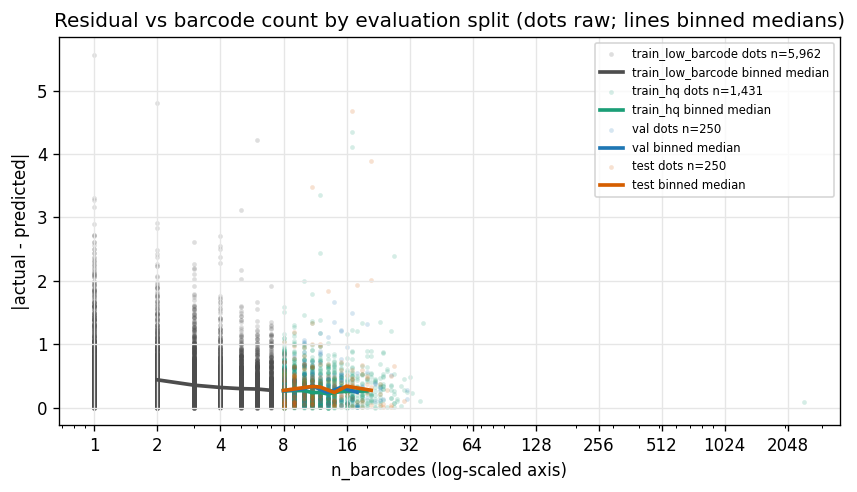

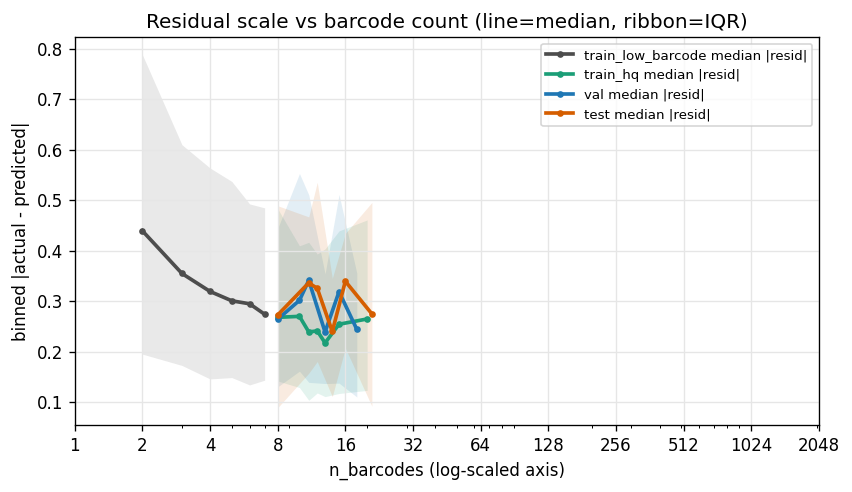

In [17]:
# promoter 
if 'checkpoint_eval_predictions' in globals():
    fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id='cqg85h6j', absolute=False)
    fig, ax = plot_residual_vs_barcode_combined(checkpoint_eval_predictions, run_id='cqg85h6j', absolute=True)
    fig, ax = plot_binned_residual_scale_vs_barcode(checkpoint_eval_predictions, run_id='cqg85h6j')
else:
    print('Residual plots skipped. Run checkpoint evaluation first to create checkpoint_eval_predictions.')

## Paired Bootstrap On Shared Row IDs

Use this only after generating `checkpoint_eval_predictions` above.

A paired comparison is valid only when two models are evaluated on the same row IDs for the same split. This is why shared `split_seed` matters. The merge below pairs predictions by `row_id`; if two runs have different heldout rows, `pair_n` will be small or zero and the comparison should not be interpreted.

Delta convention:

```text
delta = metric(left run) - metric(right run)
```

For Pearson/Spearman/COD R2, positive favors the left run. For RMSE, negative favors the left run.

In [18]:
def metric_value(y_true, y_pred, metric):
    if metric == 'pearson':
        return pearson_np(y_true, y_pred)
    if metric == 'spearman':
        return spearman_np(y_true, y_pred)
    if metric == 'rmse':
        return rmse_np(y_true, y_pred)
    if metric == 'cod_r2':
        return cod_r2_np(y_true, y_pred)
    raise ValueError(metric)


def paired_bootstrap_delta(frame_left, frame_right, metrics=('pearson', 'spearman', 'rmse'), n_boot=5000, seed=7):
    merge_cols = ['row_id']
    left = frame_left[merge_cols + ['true_raw', 'pred_raw']].rename(columns={'pred_raw': 'pred_left', 'true_raw': 'true_left'})
    right = frame_right[merge_cols + ['true_raw', 'pred_raw']].rename(columns={'pred_raw': 'pred_right', 'true_raw': 'true_right'})
    paired = left.merge(right, on=merge_cols, how='inner')
    paired = paired[np.isfinite(paired['true_left']) & np.isfinite(paired['pred_left']) & np.isfinite(paired['pred_right'])].copy()
    # Same row_id should mean same truth; keep left truth and optionally audit mismatch.
    y = paired['true_left'].to_numpy(dtype=float)
    p_left = paired['pred_left'].to_numpy(dtype=float)
    p_right = paired['pred_right'].to_numpy(dtype=float)
    n = len(paired)
    rows = []
    if n < 4:
        return pd.DataFrame([{'metric': metric, 'pair_n': n, 'delta': np.nan, 'ci_low': np.nan, 'ci_high': np.nan} for metric in metrics])
    rng = np.random.default_rng(seed)
    boot_idx = rng.integers(0, n, size=(int(n_boot), n))
    for metric in metrics:
        obs_left = metric_value(y, p_left, metric)
        obs_right = metric_value(y, p_right, metric)
        deltas = []
        for idx in boot_idx:
            deltas.append(metric_value(y[idx], p_left[idx], metric) - metric_value(y[idx], p_right[idx], metric))
        deltas = np.asarray(deltas, dtype=float)
        deltas = deltas[np.isfinite(deltas)]
        lo, hi = np.percentile(deltas, [2.5, 97.5]) if len(deltas) else (np.nan, np.nan)
        rows.append({
            'metric': metric,
            'pair_n': n,
            'left_value': obs_left,
            'right_value': obs_right,
            'delta_left_minus_right': obs_left - obs_right,
            'ci_low': lo,
            'ci_high': hi,
            'ci_excludes_0': bool((lo > 0) or (hi < 0)) if np.isfinite(lo) and np.isfinite(hi) else False,
        })
    return pd.DataFrame(rows)


def all_pairwise_bootstrap(predictions, eval_split='val', n_boot=2000):
    rows = []
    split_df = predictions[predictions['eval_split'].eq(eval_split)].copy()
    for (region, split_seed), group in split_df.groupby(['cre_region', 'split_seed'], dropna=False):
        run_ids = sorted(group['run_id'].astype(str).unique())
        for left_id, right_id in combinations(run_ids, 2):
            left = group[group['run_id'].astype(str).eq(left_id)]
            right = group[group['run_id'].astype(str).eq(right_id)]
            comp = paired_bootstrap_delta(left, right, n_boot=n_boot)
            comp['cre_region'] = region
            comp['split_seed'] = split_seed
            comp['eval_split'] = eval_split
            comp['left_run_id'] = left_id
            comp['right_run_id'] = right_id
            rows.append(comp)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()



def plot_pairwise_bootstrap_delta(bootstrap_df, metric='pearson', title=None):
    plot_df = bootstrap_df[bootstrap_df['metric'].eq(metric)].copy()
    if plot_df.empty:
        raise ValueError(f'No bootstrap rows for metric={metric!r}')
    plot_df = plot_df.sort_values(['cre_region', 'split_seed', 'eval_split', 'delta_left_minus_right'])
    labels = plot_df.apply(
        lambda r: f"{r['cre_region']} seed={r['split_seed']} {r['eval_split']}\n{r['left_run_id']} - {r['right_run_id']}",
        axis=1,
    )
    y = np.arange(len(plot_df))
    delta = plot_df['delta_left_minus_right'].to_numpy(dtype=float)
    lo = plot_df['ci_low'].to_numpy(dtype=float)
    hi = plot_df['ci_high'].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(8.2, max(4, 0.42 * len(plot_df))))
    ax.errorbar(delta, y, xerr=[delta - lo, hi - delta], fmt='o', color='#333333', ecolor='#777777', capsize=3)
    ax.axvline(0, color='#d55e00', linewidth=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel(f'Delta {metric}: left - right')
    ax.set_title(title or f'Paired bootstrap delta CI for {metric}')
    ax.grid(axis='x', color='0.9')
    fig.tight_layout()
    return fig, ax

# After heavy eval:
if 'checkpoint_eval_predictions' in globals():
    val_pairwise_bootstrap = all_pairwise_bootstrap(checkpoint_eval_predictions, eval_split='val', n_boot=2000)
    test_pairwise_bootstrap = all_pairwise_bootstrap(checkpoint_eval_predictions, eval_split='test', n_boot=2000)
    display(val_pairwise_bootstrap)
else:
    print('Paired bootstrap skipped. Run checkpoint evaluation first to create checkpoint_eval_predictions.')


,metric,pair_n,left_value,right_value,delta_left_minus_right,ci_low,ci_high,ci_excludes_0,cre_region,split_seed,eval_split,left_run_id,right_run_id
0,pearson,194,0.379558,0.409130,-0.029572,-0.187551,0.152335,False,3UTR,303,val,39glhfll,pn50zxhm
1,spearman,194,0.318513,0.212301,0.106212,-0.019935,0.231864,False,3UTR,303,val,39glhfll,pn50zxhm
2,rmse,194,0.871296,0.867018,0.004278,-0.049722,0.064476,False,3UTR,303,val,39glhfll,pn50zxhm
3,pearson,250,0.545004,0.540648,0.004355,-0.059615,0.066631,False,5UTR,101,val,4a2z7obx,n9lzq306
4,spearman,250,0.540270,0.536952,0.003318,-0.070034,0.079848,False,5UTR,101,val,4a2z7obx,n9lzq306
5,rmse,250,0.368217,0.391282,-0.023065,-0.049050,0.003734,False,5UTR,101,val,4a2z7obx,n9lzq306
6,pearson,250,0.453966,0.468863,-0.014896,-0.092968,0.062984,False,5UTR,303,val,a5zoy95n,yydnds86
7,spearman,250,0.462358,0.484986,-0.022628,-0.099640,0.050357,False,5UTR,303,val,a5zoy95n,yydnds86
8,rmse,250,0.428025,0.864366,-0.436341,-0.501150,-0.368021,True,5UTR,303,val,a5zoy95n,yydnds86
9,pearson,250,0.249752,0.240553,0.009199,-0.114476,0.129403,False,Enhancer,202,val,f0e9s0ef,rbdf02tt



## Decision Notes From This Notebook

Use the actual outputs above to fill these in after execution:

1. Exact config repeatability across split seeds:
   - If `repeated_across_split_seed` is empty, do not claim config-level seed stability from HPO. The sweep explored split seed and hyperparameters jointly.
2. Shared heldout splits:
   - Runs with the same CRE part and `split_seed` should share deterministic val/test row IDs. The notebook reconstructs and hashes those IDs as a sanity check. A mismatch for the same part/data policy/`split_seed` would indicate a split-control bug.
3. Fisher CIs:
   - Use leader CI plots to avoid overinterpreting small val/test Pearson differences. Remember that `selected_by_test_pearson_diagnostic` is not a valid primary selection rule if test is meant to remain final heldout evidence.
4. Low-barcode diagnosis:
   - If `train_low_barcode` has much wider residuals and worse COD R2/Pearson than `train_hq`, the train<val pattern is likely caused by noisier low-barcode labels.
5. HPO stochasticity design:
   - If `split_seed` is treated as a normal HPO parameter, config quality and split difficulty are entangled.
   - If `split_seed` is treated as an outer loop, each proposed config is evaluated on the same seed set and can be scored by mean validation Pearson, standard deviation, CI, or win consistency.
   - A fixed `model_seed` during broad discovery is a reasonable cost-control choice if the immediate goal is split robustness. Repeating shortlisted configs across multiple `model_seed` values is optional and mainly useful when top configs are close or training randomness looks large.
6. Downsampling prerequisite:
   - Finish this evaluation before launching downsampling. Future downsampling should downsample original variants first, then sweep RC off/on on the same subset.



## Outer-Seed Prior Manifest Prototype

This section prototypes the follow-up HPO manifest described in `plan/phase1_lib1/lib1_outer_seed_prior_hpo_plan_june2026.md`.

Design encoded here:

- one architecture per part;
- no RC in this follow-up (`use_reverse_complements=False`);
- 30 base configs per part: 8 exact elite observed configs, 12 local variants, 10 narrowed-prior samples;
- 5 split seeds per base config;
- fixed `model_seed=1701`.

The generated tables are meant for manual review first. After review, an implementation agent can lift this logic into a `src/learn` script and a global-queue launcher.


In [19]:

OUTER_SEED_PART_PRIORS = {
    'Promoter': {
        'architecture': 'BassetVL',
        'model_module': 'PromoterBassetVL',
        'logger_project': 'promoter__bashor_in_house__lib1_allvalid__scratch__promoter_bassetvl',
        'prior_sweep_id': 'vi17zxcm',
    },
    'Intron': {
        'architecture': 'ResNet1D',
        'model_module': 'ResNet1DRegressor',
        'logger_project': 'introns__bashor_in_house__lib1_intron_modal80__scratch__resnet1d',
        'prior_sweep_id': '5b0njbjz',
    },
    '3UTR': {
        'architecture': 'ResNet1D',
        'model_module': 'ResNet1DRegressor',
        'logger_project': 'utr3__bashor_in_house__threeprime_modal100__scratch__resnet1d_fp32',
        'prior_sweep_id': 'bnyvegba',
    },
    '5UTR': {
        'architecture': 'ResNet1D',
        'model_module': 'ResNet1DRegressor',
        'logger_project': 'utr5__bashor_in_house__fiveprime_modal50__scratch__resnet1d_fp32',
        'prior_sweep_id': '87uud4bc',
    },
}
OUTER_SEED_SPLIT_SEEDS = [101, 202, 303, 404, 505]
OUTER_SEED_MODEL_SEED = 1701
N_EXACT_ELITE = 8
N_LOCAL_VARIANT = 12
N_NARROW_PRIOR = 10
WRITE_MANIFEST_FILES = False
MANIFEST_OUTDIR = REPO / 'src' / 'learn' / 'outputs' / 'hpo_manifests'
MANIFEST_TAG = 'lib1_outer_seed_prior_no_rc_june2026'

# Hyperparameter keys used to define repeated configs. Seeds and RC are handled by the manifest expansion.
RESNET_MANIFEST_KEYS = [
    'optimizer', 'lr', 'weight_decay', 'amsgrad', 'beta1', 'beta2', 'scheduler', 'T_0',
    'batch_size', 'use_batch_norm', 'stem_channels', 'stem_kernel_size',
    'block_kernel_size', 'dropout_p', 'head_hidden_channels',
]
BASSET_MANIFEST_KEYS = [
    'optimizer', 'lr', 'weight_decay', 'amsgrad', 'beta1', 'beta2', 'scheduler',
    'batch_size', 'use_batch_norm', 'conv1_channels', 'conv1_kernel_size',
    'conv2_channels', 'conv2_kernel_size', 'conv3_channels', 'conv3_kernel_size',
    'adaptive_pool_output_size', 'n_linear_layers', 'linear_channels',
    'linear_activation', 'linear_dropout_p',
]

# Narrow priors from the previous HPO top-validation region. These encode intentionally broad supports,
# not hard claims that the previous winners are true optima.
OUTER_SEED_SPECS = {
    'Promoter': {
        'keys': BASSET_MANIFEST_KEYS,
        'log': {'lr': (1e-4, 1e-3), 'weight_decay': (1e-5, 2e-3)},
        'uniform': {'linear_dropout_p': (0.38, 0.65), 'beta1': (0.84, 0.96), 'beta2': (0.988, 0.999)},
        'int': {'conv1_channels': (48, 128), 'conv2_channels': (40, 128), 'conv3_channels': (24, 96), 'linear_channels': (50, 192)},
        'categorical': {
            'optimizer': ['AdamW'], 'scheduler': ['None'], 'amsgrad': [False, True],
            'batch_size': [64, 128, 256], 'use_batch_norm': [True, False],
            'conv1_kernel_size': [5, 7, 9, 11], 'conv2_kernel_size': [7, 9, 3, 5],
            'conv3_kernel_size': [7, 5, 3], 'adaptive_pool_output_size': [12, 8, 6],
            'n_linear_layers': [2, 1], 'linear_activation': ['LeakyReLU', 'ELU', 'ReLU'],
        },
    },
    'Intron': {
        'keys': RESNET_MANIFEST_KEYS,
        'log': {'lr': (3e-5, 4e-4), 'weight_decay': (2e-6, 2e-3)},
        'uniform': {'dropout_p': (0.07, 0.40), 'beta1': (0.88, 0.95), 'beta2': (0.985, 0.996)},
        'int': {'stem_channels': (36, 96), 'head_hidden_channels': (32, 160)},
        'categorical': {
            'optimizer': ['Adam', 'AdamW'], 'scheduler': ['CosineAnnealingWarmRestarts', 'None'],
            'T_0': [500, 1000, 2000], 'amsgrad': [False, True], 'batch_size': [256, 128],
            'use_batch_norm': [False, True], 'stem_kernel_size': [7, 9, 5, 3],
            'block_kernel_size': [9, 7, 5, 3],
        },
    },
    '3UTR': {
        'keys': RESNET_MANIFEST_KEYS,
        'log': {'lr': (3e-5, 4e-4), 'weight_decay': (1e-6, 3e-5)},
        'uniform': {'dropout_p': (0.08, 0.40), 'beta1': (0.84, 0.95), 'beta2': (0.985, 0.999)},
        'int': {'stem_channels': (54, 128), 'head_hidden_channels': (76, 256)},
        'categorical': {
            'optimizer': ['Adam', 'AdamW'], 'scheduler': ['None', 'CosineAnnealingWarmRestarts'],
            'T_0': [500, 1000, 2000], 'amsgrad': [True, False], 'batch_size': [64, 128, 256],
            'use_batch_norm': [False, True], 'stem_kernel_size': [5, 7], 'block_kernel_size': [3, 5],
        },
    },
    '5UTR': {
        'keys': RESNET_MANIFEST_KEYS,
        'log': {'lr': (3e-5, 1.5e-4), 'weight_decay': (1e-6, 5e-4)},
        'uniform': {'dropout_p': (0.16, 0.40), 'beta1': (0.84, 0.92), 'beta2': (0.985, 0.998)},
        'int': {'stem_channels': (50, 160), 'head_hidden_channels': (100, 256)},
        'categorical': {
            'optimizer': ['AdamW', 'Adam'], 'scheduler': ['CosineAnnealingWarmRestarts', 'None'],
            'T_0': [500, 1000, 2000], 'amsgrad': [True, False], 'batch_size': [256, 128, 64],
            'use_batch_norm': [False, True], 'stem_kernel_size': [5, 7, 11], 'block_kernel_size': [3, 5],
        },
    },
}


In [20]:

def _config_subset(cfg, keys):
    return {key: cfg.get(key) for key in keys if key in cfg and cfg.get(key) is not None}


def _freeze_value(value):
    if isinstance(value, float):
        return round(value, 10)
    if isinstance(value, list):
        return tuple(value)
    return value


def _config_fingerprint(cfg, keys):
    return tuple((key, _freeze_value(cfg.get(key))) for key in keys)


def _safe_bool(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, str):
        return value.strip().lower() in {'true', '1', 'yes'}
    if pd.isna(value):
        return np.nan
    return bool(value)


def prior_runs_for_outer_seed(part):
    info = OUTER_SEED_PART_PRIORS[part]
    df = hpo_cfg[
        hpo_cfg['logger_project'].eq(info['logger_project'])
        & hpo_cfg['wandb_sweep_id'].astype(str).eq(info['prior_sweep_id'])
        & hpo_cfg['selection_ready']
    ].copy()
    df = df[df['val_pearson'].between(-1, 1) & df['test_pearson'].between(-1, 1)].copy()
    if df.empty:
        raise ValueError(f'No prior runs for {part}')
    df['within_seed_val_pct'] = df.groupby('split_seed', dropna=False)['val_pearson'].rank(pct=True, method='average')
    df['prior_selection_score'] = df['within_seed_val_pct'] if df['split_seed'].nunique(dropna=True) > 1 else df['val_pearson'].rank(pct=True)
    return df.sort_values(['prior_selection_score', 'val_pearson'], ascending=False)


def dedup_prior_runs(part):
    spec = OUTER_SEED_SPECS[part]
    keys = spec['keys']
    rows = []
    seen = set()
    for _, row in prior_runs_for_outer_seed(part).iterrows():
        cfg, config_path = load_run_config(str(row['run_id']))
        cfg_subset = _config_subset(cfg, keys)
        fp = _config_fingerprint(cfg_subset, keys)
        if fp in seen:
            continue
        seen.add(fp)
        rows.append({
            'part': part,
            'architecture': OUTER_SEED_PART_PRIORS[part]['architecture'],
            'source_prior_sweep_id': OUTER_SEED_PART_PRIORS[part]['prior_sweep_id'],
            'source_run_id': row['run_id'],
            'source_val_pearson': row['val_pearson'],
            'source_test_pearson': row['test_pearson'],
            'source_split_seed': row.get('split_seed'),
            'source_model_seed': row.get('model_seed'),
            'source_use_reverse_complements': _safe_bool(row.get('use_reverse_complements')),
            'prior_selection_score': row['prior_selection_score'],
            'config_path_local': str(config_path) if config_path else None,
            **cfg_subset,
        })
    return pd.DataFrame(rows)


def sample_log_uniform(rng, lo, hi):
    return float(np.exp(rng.uniform(np.log(lo), np.log(hi))))


def sample_from_spec(part, rng):
    spec = OUTER_SEED_SPECS[part]
    cfg = {}
    for key, (lo, hi) in spec.get('log', {}).items():
        cfg[key] = sample_log_uniform(rng, lo, hi)
    for key, (lo, hi) in spec.get('uniform', {}).items():
        cfg[key] = float(rng.uniform(lo, hi))
    for key, (lo, hi) in spec.get('int', {}).items():
        cfg[key] = int(rng.integers(int(lo), int(hi) + 1))
    for key, values in spec.get('categorical', {}).items():
        cfg[key] = values[int(rng.integers(0, len(values)))]
    if cfg.get('scheduler') == 'None':
        cfg['T_0'] = None
    return cfg


def jitter_from_template(part, template, rng):
    spec = OUTER_SEED_SPECS[part]
    cfg = {key: template.get(key) for key in spec['keys'] if key in template and pd.notna(template.get(key))}
    for key, (lo, hi) in spec.get('log', {}).items():
        center = float(cfg.get(key, sample_log_uniform(rng, lo, hi)))
        cfg[key] = float(np.clip(center * np.exp(rng.normal(0, 0.35)), lo, hi))
    for key, (lo, hi) in spec.get('uniform', {}).items():
        center = float(cfg.get(key, rng.uniform(lo, hi)))
        cfg[key] = float(np.clip(center + rng.normal(0, 0.12 * (hi - lo)), lo, hi))
    for key, (lo, hi) in spec.get('int', {}).items():
        center = int(cfg.get(key, rng.integers(lo, hi + 1)))
        width = max(2, int(round(0.20 * (hi - lo))))
        cfg[key] = int(np.clip(center + rng.integers(-width, width + 1), lo, hi))
    for key, values in spec.get('categorical', {}).items():
        if key not in cfg or rng.random() < 0.25:
            cfg[key] = values[int(rng.integers(0, len(values)))]
    if cfg.get('scheduler') == 'None':
        cfg['T_0'] = None
    elif cfg.get('T_0') is None and 'T_0' in spec.get('categorical', {}):
        values = spec['categorical']['T_0']
        cfg['T_0'] = values[int(rng.integers(0, len(values)))]
    return cfg


def build_base_configs_for_part(part, seed=1701):
    rng = np.random.default_rng(seed + sum(ord(ch) for ch in part))
    spec = OUTER_SEED_SPECS[part]
    keys = spec['keys']
    prior_dedup = dedup_prior_runs(part)
    exact = prior_dedup.head(N_EXACT_ELITE).copy()
    rows = []
    seen = set()

    def add_row(config_source, cfg, source=None, source_idx=None):
        fp = _config_fingerprint(cfg, keys)
        tries = 0
        while fp in seen and tries < 50:
            cfg = jitter_from_template(part, cfg, rng)
            fp = _config_fingerprint(cfg, keys)
            tries += 1
        if fp in seen:
            return
        seen.add(fp)
        rows.append({
            'part': part,
            'architecture': OUTER_SEED_PART_PRIORS[part]['architecture'],
            'model_module': OUTER_SEED_PART_PRIORS[part]['model_module'],
            'source_prior_sweep_id': OUTER_SEED_PART_PRIORS[part]['prior_sweep_id'],
            'config_id': f"{part.replace(' ', '').replace('Prime', 'P')}_{len(rows) + 1:02d}",
            'config_source': config_source,
            'source_run_id': None if source is None else source.get('source_run_id'),
            'source_val_pearson': np.nan if source is None else source.get('source_val_pearson'),
            'source_test_pearson': np.nan if source is None else source.get('source_test_pearson'),
            'source_split_seed': np.nan if source is None else source.get('source_split_seed'),
            'source_use_reverse_complements': np.nan if source is None else source.get('source_use_reverse_complements'),
            **{key: cfg.get(key) for key in keys},
        })

    for _, source in exact.iterrows():
        cfg = {key: source.get(key) for key in keys if key in source and pd.notna(source.get(key))}
        add_row('exact_elite', cfg, source=source)

    exact_templates = rows[:]
    for i in range(N_LOCAL_VARIANT):
        template = exact_templates[i % len(exact_templates)]
        cfg = jitter_from_template(part, template, rng)
        add_row('local_variant', cfg, source=template)

    for _ in range(N_NARROW_PRIOR):
        cfg = sample_from_spec(part, rng)
        add_row('narrow_prior', cfg)

    base = pd.DataFrame(rows)
    if len(base) != (N_EXACT_ELITE + N_LOCAL_VARIANT + N_NARROW_PRIOR):
        raise RuntimeError(f'{part}: expected 30 base configs, got {len(base)}')
    return base


def build_outer_seed_manifest():
    base = pd.concat([build_base_configs_for_part(part) for part in OUTER_SEED_PART_PRIORS], ignore_index=True)
    expanded_rows = []
    for _, row in base.iterrows():
        for split_seed in OUTER_SEED_SPLIT_SEEDS:
            rec = row.to_dict()
            rec['split_seed'] = int(split_seed)
            rec['model_seed'] = OUTER_SEED_MODEL_SEED
            rec['use_reverse_complements'] = False
            rec['manifest_tag'] = MANIFEST_TAG
            rec['planned_run_name'] = f"{MANIFEST_TAG}_{rec['part'].replace(' ', '').lower()}_{rec['config_id']}_seed{split_seed}"
            expanded_rows.append(rec)
    expanded = pd.DataFrame(expanded_rows)
    return base, expanded

try:
    display
except NameError:
    from IPython.display import display

base_config_table, outer_seed_run_manifest = build_outer_seed_manifest()
print(f'Base configs: {len(base_config_table)} rows')
print(f'Expanded manifest: {len(outer_seed_run_manifest)} rows')
display(base_config_table.groupby(['part', 'architecture', 'config_source']).size().unstack(fill_value=0))
display(outer_seed_run_manifest.groupby(['part', 'split_seed']).size().unstack(fill_value=0))

if WRITE_MANIFEST_FILES:
    MANIFEST_OUTDIR.mkdir(parents=True, exist_ok=True)
    base_path = MANIFEST_OUTDIR / f'{MANIFEST_TAG}__base_configs.csv'
    manifest_path = MANIFEST_OUTDIR / f'{MANIFEST_TAG}__run_manifest.csv'
    base_config_table.to_csv(base_path, index=False)
    outer_seed_run_manifest.to_csv(manifest_path, index=False)
    print(f'Wrote {base_path}')
    print(f'Wrote {manifest_path}')


Base configs: 120 rows
Expanded manifest: 600 rows


,config_source,exact_elite,local_variant,narrow_prior
part,architecture,,,
3UTR,ResNet1D,8,12,10
5UTR,ResNet1D,8,12,10
Intron,ResNet1D,8,12,10
Promoter,BassetVL,8,12,10


split_seed,101,202,303,404,505
part,,,,,
3UTR,30,30,30,30,30
5UTR,30,30,30,30,30
Intron,30,30,30,30,30
Promoter,30,30,30,30,30


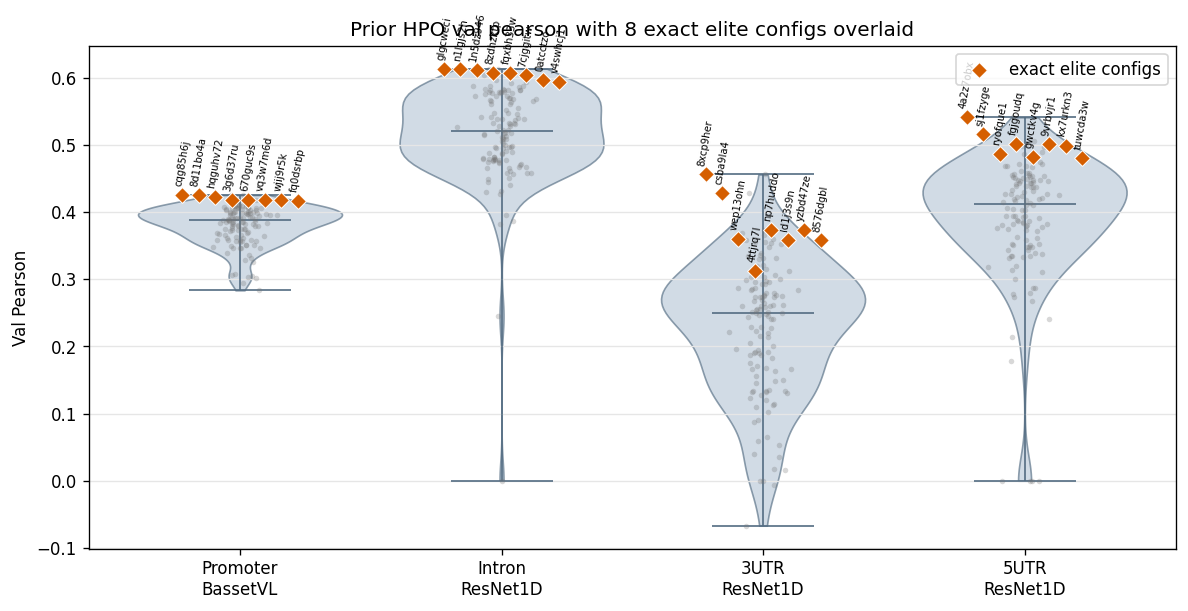

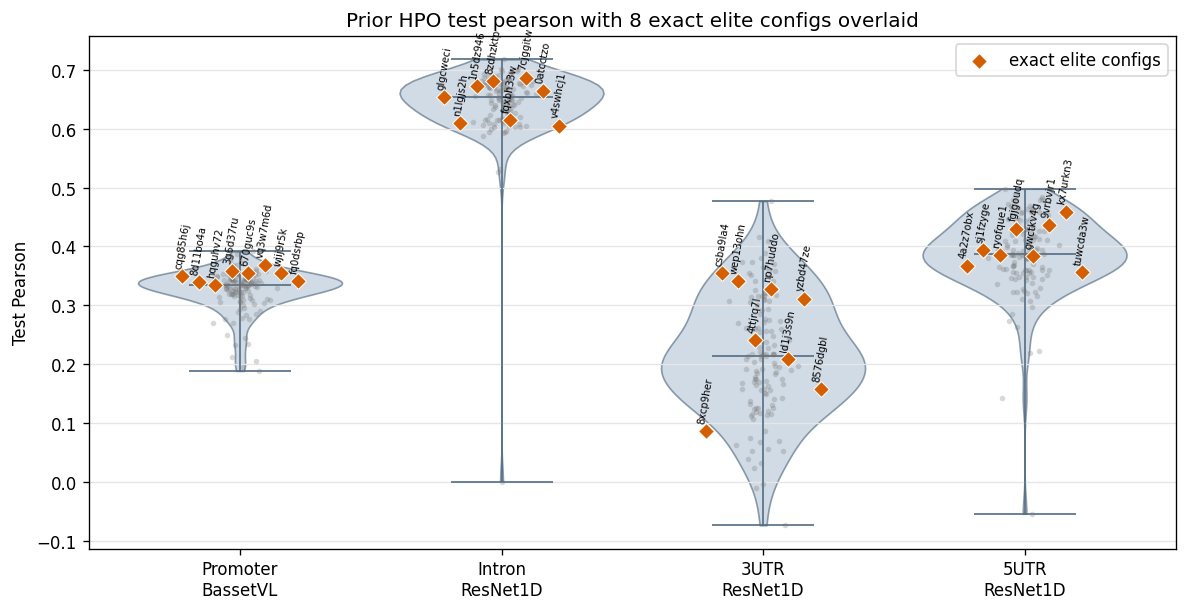

In [21]:

def prior_plot_frame_for_outer_seed():
    frames = []
    for part, info in OUTER_SEED_PART_PRIORS.items():
        df = prior_runs_for_outer_seed(part).copy()
        df['part_arch'] = f"{part}\n{info['architecture']}"
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def plot_prior_distribution_with_exact_elites(metric='val_pearson'):
    prior_df = prior_plot_frame_for_outer_seed()
    exact_df = base_config_table[base_config_table['config_source'].eq('exact_elite')].copy()
    labels = [f"{part}\n{info['architecture']}" for part, info in OUTER_SEED_PART_PRIORS.items()]
    fig, ax = plt.subplots(figsize=(10, 5.2))
    data = [prior_df.loc[prior_df['part_arch'].eq(label), metric].dropna().to_numpy(dtype=float) for label in labels]
    parts = ax.violinplot(data, positions=np.arange(len(labels)), showmeans=False, showmedians=True, widths=0.78)
    for body in parts['bodies']:
        body.set_facecolor('#b9c8d8')
        body.set_edgecolor('#536c82')
        body.set_alpha(0.65)
    for key in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
        if key in parts:
            parts[key].set_color('#536c82')
            parts[key].set_linewidth(1.0)
    rng = np.random.default_rng(2026)
    for i, label in enumerate(labels):
        sub = prior_df[prior_df['part_arch'].eq(label)]
        x = i + rng.normal(0, 0.045, size=len(sub))
        ax.scatter(x, sub[metric], s=11, color='0.45', alpha=0.28, linewidth=0, zorder=2)
    for i, label in enumerate(labels):
        part = label.split('\n')[0]
        sub = exact_df[exact_df['part'].eq(part)].copy()
        y_col = 'source_val_pearson' if metric == 'val_pearson' else 'source_test_pearson'
        x = i + np.linspace(-0.22, 0.22, len(sub))
        ax.scatter(x, sub[y_col], marker='D', s=45, color='#d55e00', edgecolor='white', linewidth=0.6, zorder=4, label='exact elite configs' if i == 0 else None)
        for xv, (_, row) in zip(x, sub.iterrows()):
            ax.text(xv, row[y_col] + 0.012, str(row['source_run_id']), rotation=80, ha='center', va='bottom', fontsize=6)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(f'Prior HPO {metric.replace("_", " ")} with 8 exact elite configs overlaid')
    ax.grid(axis='y', color='0.9')
    ax.legend(frameon=True, loc='best')
    fig.tight_layout()
    return fig, ax

fig, ax = plot_prior_distribution_with_exact_elites(metric='val_pearson')
fig, ax = plot_prior_distribution_with_exact_elites(metric='test_pearson')
